# Prediccion de JPMorgan con Transformer -- VERSION MEJORADA (comparacion)

**Este notebook es un experimento independiente para comparar contra
`JPMorgan_Transformer_General.ipynb`** (el script original), no un reemplazo.
Guarda sus propios archivos (`JPM_mejorado_*`) para no pisar el historico ni la
tabla de resultados del script original -- podes correr ambos en paralelo y
comparar sus informes/backtests lado a lado.

## Que cambia respecto al original

El notebook original entrenaba **un solo modelo** (Transformer-Encoder,
Close+SMA_5, lookback=10) y lo validaba contra un baseline de persistencia
ingenua en un backtest de ~150 dias, con un test de Wilcoxon que nunca cruzo el
umbral convencional de significancia (p=0.19 al mejor caso, en JPM). Esta
version implementa las recomendaciones concretas que salieron de leer la
bibliografia citada en el original (Lim, Arik, Loeff & Pfister 2019/2021; Zhou
et al. 2021; Zeng, Chen, Zhang & Xu 2023; Lim & Gorse 2020; Olorunnimbe & Viktor
2023; Yang et al. 2025) mas alla de solo el diseno arquitectonico:

1. **Backtest de anios, no de meses** (Olorunnimbe & Viktor, 2023): walk-forward
   sobre ~500 dias (~2 anios) en vez de ~150, para tener potencia estadistica
   real -- el problema del p=0.19 original era, sobre todo, tamano de muestra.
2. **Ensemble de semillas** (Zeng et al., 2023, promedian 5 corridas para
   reducir varianza) combinado con MC Dropout para una incertidumbre que separa
   componente epistemica (entre semillas/pasadas) y aleatoria (ancho de
   cuantiles) -- ver `md-arquitectura`.
3. **Baselines lineales DLinear/NLinear** (Zeng et al., 2023): antes de asumir
   que la complejidad del Transformer se justifica, se la compara contra un
   modelo de una sola capa lineal -- el hallazgo central de ese paper es que
   estos baselines a menudo superan a Transformers sofisticados.
4. **Feature de volumen** (Yang et al., 2025, TFT-ASRO: Shapley ~25% de
   importancia para volumen, la segunda feature mas relevante despues del
   precio).
5. **Tests estadisticos adicionales a Wilcoxon**: Diebold-Mariano (1995, con
   correccion de muestra pequena de Harvey-Leybourne-Newbold) -- mas robusto
   ante errores de pronostico autocorrelacionados -- y un bootstrap circular por
   bloques (adaptacion simplificada del remuestreo masivo de Lim & Gorse, 2020).
6. **Segmentacion por regimen de volatilidad** (Olorunnimbe & Viktor, 2023: el
   mercado no es i.i.d., una ventaja puede concentrarse en cierto regimen).
7. **Ablacion de shuffling** (Zeng et al., 2023): mezclar el orden temporal del
   input para verificar si el modelo realmente usa la dependencia temporal o si
   su ventaja es solo estadistica agregada.
8. **Barrido del umbral del gate de confianza**: el original exigia 1 sigma
   completo y eso dejo la estrategia simulada con posicion en apenas 1 de 146
   dias -- aqui se barre el umbral para ver el trade-off retorno/Sharpe/numero de
   operaciones en vez de fijarlo a mano.

## Nota metodologica honesta

Ninguna de estas mejoras garantiza que el modelo "gane": si despues de todo esto
el Wilcoxon/Diebold-Mariano siguen sin cruzar el umbral de significancia, esa
sigue siendo la conclusion correcta a reportar -- el objetivo es que la prueba
sea mas rigurosa y mas dificil de malinterpretar, no forzar un resultado
positivo. Ver `md-cierre` para como leer la recomendacion final antes de operar
con dinero real en Hapi.

## Como se usa

Igual que el original: SETUP una vez, PREDICCION/REVELACION cada dia nuevo para
el ciclo diario a 1 dia, e INFORME + BACKTEST cuando necesites la decision
completa a 5 dias. La celda de BACKTEST puede tardar bastante (ver aviso de
tiempo de ejecucion en esa celda) porque ahora recorre anios de historico en vez
de meses -- correla una sola vez y reusa `BACKTEST_METRICS` para el INFORME.

## Guia rapida: que hace cada celda (para no perderte corriendo esto seguido)

El **orden fisico de las celdas ya sigue este mismo orden** -- vas corriendo de
arriba hacia abajo y no te tenes que saltear nada:

| # | Celda | Cuando correrla | Que hace, en criollo |
|---|-------|------------------|----------------------|
| 1 | **setup** | Una sola vez, al abrir la sesion | Prepara todo: conecta tu Google Drive, carga el historico de precios, define el modelo. Todavia no predice nada. |
| 2 | **backtest** | Justo despues de `setup`, **una sola vez** (no hace falta repetirla cada dia) | Prueba el modelo contra ~2 anios de historia para saber si de verdad funciona mejor que el azar. **Tarda bastante** (de varios minutos a un par de horas) -- es normal, no se colgo. |
| 3 | **informe** | Despues de `backtest` (asi sale con las metricas completas, no con "None") | Entrena un modelo aparte a 5 dias y te da la recomendacion (comprar/mantener/vender) con take profit/stop loss. |
| 4 | **predict** | Una vez por dia, de ahi en adelante, cuando quieras un pronostico nuevo | Entrena con lo que ya sabes hasta hoy y predice a ciegas el cierre del proximo dia habil (1 dia, no 5 -- ese es el trabajo de `informe`). |
| 5 | **reveal** | Justo despues de `predict`, cuando ya sepas el cierre real | Te pide que escribas el precio (y volumen) real de ese dia, calcula el error, y lo guarda en tu historial acumulado. |

**Regla practica**: corre `setup` -> `backtest` -> `informe` una vez, en ese
orden, al empezar (`backtest` tarda, pero solo se hace una vez). De ahi en
adelante, tu rutina diaria es solo `predict` + `reveal`, repetidas cada dia.
Volve a correr `informe` solo cuando necesites decidir una operacion real.


## Arquitectura: Transformer multi-tarea + ensemble

Mismo `d_model`, `n_heads`, `d_ff`, `n_layers`, `lookback` que el script
original -- la comparacion busca aislar el efecto de las mejoras
*metodologicas* (features, incertidumbre, tests, tamano de backtest), no el de
agrandar la red a ciegas.

Lo que cambia es la salida del modelo: en vez de una unica prediccion puntual,
cada modelo tiene **dos cabezas**:

- **Cabeza de cuantiles** (`q10, q50, q90`): regresion cuantilica (Lim, Arik,
  Loeff & Pfister, 2019/2021 -- el TFT original usa esto para incertidumbre, no
  MC Dropout). La mediana (`q50`) es la prediccion puntual; el ancho
  `q90 - q10` da una medida de incertidumbre *aleatoria* (del dato).
- **Cabeza auxiliar de volatilidad**: predice la volatilidad realizada de los
  proximos `horizon` dias como tarea secundaria (Yang et al., 2025, TFT-ASRO:
  aprender retorno + volatilidad simultaneamente mejora la robustez de las
  representaciones internas del modelo).

Sobre esto se aplican dos capas de remuestreo para la incertidumbre final:

- **MC Dropout** (Gal & Ghahramani, 2016) dentro de cada modelo: varianza
  *epistemica* intra-modelo.
- **Ensemble de semillas** (`N_SEEDS_LIVE` / `N_SEEDS_BACKTEST` modelos
  entrenados con distinta inicializacion): varianza *epistemica* entre
  corridas, formalizada como deep ensemble (Lakshminarayanan et al., 2017 --
  extension natural de "promediar varias corridas", que Zeng et al. 2023 hacen
  para controlar varianza al comparar arquitecturas).

La incertidumbre final combina las tres fuentes por ley de varianza total:
`Var_total = E[Var_epistemica_intra] + Var[medias entre semillas] + E[Var_aleatoria]`.


In [1]:
# >>> QUE HACE ESTA CELDA: prepara todo (Drive, datos, arquitectura del modelo).
# >>> CUANDO CORRERLA: una sola vez, al abrir la sesion. No genera ninguna prediccion.

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ---------- Paleta validada para los graficos (dataviz skill, palette.md) ----------
# Categorica en orden fijo (nunca ciclada): azul=ensemble, naranja=DLinear, aqua=NLinear.
# El cierre real usa tinta oscura (no es "una serie mas": es la referencia contra la
# que se comparan todas). El baseline naive usa gris muted -- se compara, pero no
# compite visualmente por atencion.
INK = '#0b0b0b'
INK_SECUNDARIA = '#52514e'
MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'
SLOT_AZUL = '#2a78d6'      # ensemble (la serie protagonista)
SLOT_NARANJA = '#eb6834'   # DLinear
SLOT_AQUA = '#1baf7a'      # NLinear
GOOD = '#0ca30c'           # COMPRAR
CRITICAL = '#d03b3b'       # VENDER


def _estilo_base(ax, titulo, ylabel):
    '''Estilo compartido por todos los graficos del notebook -- fondo, grid en
    hairline, ejes recesivos, sin doble eje nunca.'''
    ax.set_title(titulo, fontsize=13, fontweight='bold', color=INK, pad=12)
    ax.set_ylabel(ylabel, fontsize=10, color=INK_SECUNDARIA)
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#c3c2b7')
    ax.tick_params(colors=INK_SECUNDARIA, labelsize=9)

from scipy.stats import wilcoxon, t as t_dist

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_FOLDER = '/content/drive/MyDrive/ade_ifs'
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
    print(f"Google Drive montado. Los archivos se guardan en: {DRIVE_FOLDER}")
except ImportError:
    DRIVE_FOLDER = '.'

# ---------- Hiperparametros ----------
# D_MODEL/N_HEADS/D_FF/N_LAYERS/LOOKBACK identicos al script original -- la
# comparacion busca aislar el efecto de las mejoras metodologicas (features,
# ensemble, incertidumbre, tests estadisticos, tamano de backtest), no el de
# agrandar la arquitectura a ciegas.
LOOKBACK = 10
HORIZON = 1
FEATURES = ['Close', 'SMA_5', 'Volume_log']
N_FEATURES = len(FEATURES)
CLOSE_IDX = FEATURES.index('Close')
SMA_IDX = FEATURES.index('SMA_5')
D_MODEL = 64
N_HEADS = 4
D_FF = 256
N_LAYERS = 2
DROPOUT = 0.1
QUANTILES = [0.1, 0.5, 0.9]
LAMBDA_VOL = 0.1
N_SEEDS_LIVE = 5          # ensemble para el ciclo diario / informe (Zeng et al. 2023: promediar corridas reduce varianza)
N_SEEDS_BACKTEST = 3      # ensemble mas chico dentro del backtest walk-forward por costo computacional
HORIZON_INFORME = 5       # horizonte del INFORME y del BACKTEST (5 dias habiles)
GATE_SIGMA = 0.5          # umbral del gate de confianza, en desvios estandar -- AJUSTAR
                          # segun la tabla de barrido de umbral que arroja la celda de
                          # BACKTEST. El script original usaba 1.0 (exigir el cambio
                          # predicho > 1 sigma completo) y eso dejo la estrategia con
                          # posicion en apenas 1 de 146 dias -- demasiado conservador.
                          # 0.5 es un punto de partida razonable, no un valor definitivo.
COLOR_MODELO = '#E76F51'  # distinto del original (#2A9D8F) para diferenciar visualmente en los graficos

# Metricas de referencia del backtest RIGUROSO (celda de BACKTEST) -- arrancan en
# None; la celda de BACKTEST las completa con .update(...) la primera vez que la
# corras en la sesion. Si corres INFORME antes que BACKTEST, el resumen de
# validacion del informe se va a ver con placeholders -- por eso el orden
# recomendado en este notebook es SETUP -> BACKTEST -> INFORME -> PREDICCION/REVELACION.
BACKTEST_METRICS = {
    'periodo': 'Corre la celda de BACKTEST antes para completar este resumen',
    'MAE_ensemble': None, 'MAE_naive': None, 'MAE_dlinear': None, 'MAE_nlinear': None,
    'precision_direccional_pct': None,
    'wilcoxon_p_value': None, 'diebold_mariano_p_value': None, 'block_bootstrap_p_value': None,
    'retorno_acumulado_estrategia_pct': None, 'sharpe_estrategia': None, 'max_drawdown_estrategia_pct': None,
    'retorno_acumulado_buy_hold_pct': None, 'sharpe_buy_hold': None, 'max_drawdown_buy_hold_pct': None,
}

CSV_ORIGINAL = os.path.join(DRIVE_FOLDER, "JPMorgan Stock Price History.csv")
HIST_CONFIRMADO_PATH = os.path.join(DRIVE_FOLDER, "JPM_mejorado_historico_confirmado.csv")
RESULTADOS_PATH = os.path.join(DRIVE_FOLDER, "JPM_mejorado_tabla_resultados.csv")
CUTOFF_INICIAL = pd.Timestamp('2026-07-27')


def cargar_investing_csv_con_volumen(path):
    '''Como el loader del script original, pero conserva el volumen (columna
    "Vol.", formato "6.25M") en vez de descartarlo -- Yang et al. (2025, TFT-ASRO)
    reportan ~25% de importancia relativa (Shapley) para el volumen, la segunda
    feature mas importante despues del precio.'''
    df_raw = pd.read_csv(path)
    df_raw = df_raw.rename(columns={'Date': 'Date', 'Price': 'Close', 'Vol.': 'Volume'})
    df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='%m/%d/%Y')
    df_raw['Close'] = df_raw['Close'].astype(str).str.replace(',', '', regex=False).astype(float)

    def parse_volumen(v):
        v = str(v).strip()
        if v in ('', '-', 'nan', 'None'):
            return np.nan
        mult = 1.0
        if v.endswith('M'):
            mult, v = 1e6, v[:-1]
        elif v.endswith('K'):
            mult, v = 1e3, v[:-1]
        elif v.endswith('B'):
            mult, v = 1e9, v[:-1]
        return float(v.replace(',', '')) * mult

    df_raw['Volume'] = df_raw['Volume'].apply(parse_volumen)
    for col in ['Open', 'High', 'Low']:
        df_raw[col] = None
    return df_raw[['Date', 'Open', 'Close', 'High', 'Low', 'Volume']]


if os.path.exists(HIST_CONFIRMADO_PATH):
    df_actual = pd.read_csv(HIST_CONFIRMADO_PATH, parse_dates=['Date'])
    print(f"Historico confirmado recuperado de sesion anterior: {len(df_actual)} filas "
          f"(hasta {df_actual['Date'].max().date()}).")
else:
    df_raw = cargar_investing_csv_con_volumen(CSV_ORIGINAL)
    df_raw = df_raw.sort_values('Date').drop_duplicates(subset='Date', keep='last').reset_index(drop=True)
    df_actual = df_raw[df_raw['Date'] <= CUTOFF_INICIAL].reset_index(drop=True).copy()
    print(f"Arrancando desde cero: {len(df_actual)} filas (hasta {df_actual['Date'].max().date()}).")

if os.path.exists(RESULTADOS_PATH):
    tabla_resultados = pd.read_csv(RESULTADOS_PATH, parse_dates=['fecha_prediccion'])
    print(f"Tabla de resultados recuperada: {len(tabla_resultados)} predicciones previas.")
else:
    tabla_resultados = pd.DataFrame(columns=[
        'fecha_prediccion', 'prediccion', 'baseline', 'real',
        'error_transformer', 'error_baseline',
        'error_pct_transformer', 'error_pct_baseline',
        'direccion_correcta'
    ])


# ---------- Arquitectura ----------
class PositionalEncoding(nn.Module):
    '''Codificacion posicional sinusoidal (Vaswani et al., 2017, seccion 3.5).'''
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class TransformerForecasterMTL(nn.Module):
    '''Extension multi-tarea del Transformer-Encoder original: en vez de una sola
    salida puntual, predice 3 cuantiles (Lim, Arik, Loeff & Pfister -- TFT usa
    regresion cuantilica para incertidumbre, no MC Dropout) y, como cabeza
    auxiliar, la volatilidad realizada del horizonte (Yang et al. 2025, TFT-ASRO:
    aprender retorno+volatilidad simultaneamente mejora la robustez de las
    representaciones). Combinado con MC Dropout se obtienen dos fuentes de
    incertidumbre: aleatoria (ancho del intervalo de cuantiles) y epistemica
    (varianza entre pasadas de dropout / entre semillas del ensemble).'''
    def __init__(self, n_features, d_model, n_heads, d_ff, n_layers, n_quantiles=3, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head_quantiles = nn.Linear(d_model, n_quantiles)
        self.head_vol = nn.Linear(d_model, 1)

    def forward(self, x):
        z = self.embedding(x)
        z = self.pos_encoder(z)
        z = self.encoder(z)
        z_last = z[:, -1, :]
        q = self.head_quantiles(z_last)
        vol = torch.nn.functional.softplus(self.head_vol(z_last))
        return q, vol


class NLinearBaseline(nn.Module):
    '''Baseline lineal (Zeng, Chen, Zhang & Xu, 2023, "Are Transformers Effective
    for Time Series Forecasting?"): resta el ultimo valor de cada canal antes de
    una unica capa lineal. Su hallazgo central -- que un modelo lineal de una capa
    a menudo supera a Transformers sofisticados -- es la comparacion obligatoria
    antes de justificar la complejidad del Transformer de este notebook.'''
    def __init__(self, lookback, n_features):
        super().__init__()
        self.linear = nn.Linear(lookback * n_features, 1)

    def forward(self, x):
        last = x[:, -1:, :]
        x_norm = x - last
        return self.linear(x_norm.reshape(x_norm.size(0), -1))


class DLinearBaseline(nn.Module):
    '''Version simplificada de DLinear (Zeng et al. 2023): en vez de un AvgPool
    generico para separar tendencia/estacionalidad, reutiliza SMA_5 (ya presente
    como feature) como tendencia y Close-SMA_5 como componente estacional/residual
    -- dos cabezas lineales independientes, sumadas.'''
    def __init__(self, lookback, close_idx, sma_idx):
        super().__init__()
        self.close_idx = close_idx
        self.sma_idx = sma_idx
        self.linear_trend = nn.Linear(lookback, 1)
        self.linear_seasonal = nn.Linear(lookback, 1)

    def forward(self, x):
        close = x[:, :, self.close_idx]
        trend = x[:, :, self.sma_idx]
        seasonal = close - trend
        out_trend = self.linear_trend(trend - trend[:, -1:])
        out_seasonal = self.linear_seasonal(seasonal - seasonal[:, -1:])
        return out_trend + out_seasonal


def build_windows_horizonte(data, lookback, horizon, target_idx=0):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i + lookback, :])
        y.append(data[i + lookback + horizon - 1, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def calcular_volatilidad_objetivo(close_array, lookback, horizon, n_ventanas):
    '''Volatilidad realizada (desvio estandar de retornos log) en los `horizon`
    dias siguientes al final de cada ventana -- target de la cabeza auxiliar.'''
    log_ret = np.diff(np.log(close_array))
    vol_full = np.full(len(close_array), np.nan)
    for i in range(len(close_array) - horizon):
        vol_full[i] = np.std(log_ret[i:i + horizon])
    vol_target = np.array([
        vol_full[i + lookback - 1] if not np.isnan(vol_full[i + lookback - 1]) else 0.0
        for i in range(n_ventanas)
    ], dtype=np.float32).reshape(-1, 1)
    return vol_target


def pinball_loss(preds, target, quantiles):
    losses = []
    for i, q in enumerate(quantiles):
        e = target - preds[:, i:i + 1]
        losses.append(torch.max((q - 1) * e, q * e))
    return torch.mean(torch.cat(losses, dim=1))


def train_model_mtl(model, X_train, y_train, vol_train, X_val, y_val, vol_val,
                     quantiles, lambda_vol=0.1, epochs=150, lr=1e-3, batch_size=32,
                     patience=20, verbose=True):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    mse = nn.MSELoss()
    best_val, best_state, patience_ctr = float('inf'), None, 0
    n_train = X_train.shape[0]
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n_train)
        running = 0.0
        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb, vb = X_train[idx], y_train[idx], vol_train[idx]
            optimizer.zero_grad()
            q_pred, vol_pred = model(xb)
            loss = pinball_loss(q_pred, yb, quantiles) + lambda_vol * mse(vol_pred, vb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        running /= n_train
        model.eval()
        with torch.no_grad():
            q_val, vol_val_pred = model(X_val)
            val_loss = (pinball_loss(q_val, y_val, quantiles) + lambda_vol * mse(vol_val_pred, vol_val)).item()
        if val_loss < best_val:
            best_val, best_state, patience_ctr = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
        if verbose and (epoch == 1 or epoch % 20 == 0):
            print(f"  Epoca {epoch:3d} | train_loss={running:.6f} | val_loss={val_loss:.6f}")
        if patience_ctr >= patience:
            if verbose:
                print(f"  Early stopping en la epoca {epoch} (mejor val_loss={best_val:.6f})")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def train_linear_baseline(model, X_train, y_train, X_val, y_val, epochs=200, lr=1e-2, patience=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    mse = nn.MSELoss()
    best_val, best_state, patience_ctr = float('inf'), None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        loss = mse(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = mse(model(X_val), y_val).item()
        if val_loss < best_val:
            best_val, best_state, patience_ctr = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def inverse_close(scaled_value, scaler, n_features, close_idx=0):
    dummy = np.zeros((1, n_features))
    dummy[0, close_idx] = scaled_value
    return scaler.inverse_transform(dummy)[0, close_idx]


def predict_mtl_con_incertidumbre(model, x_input, n_mc=50):
    '''MC Dropout (Gal & Ghahramani, 2016) sobre un modelo que ya predice
    cuantiles: cada pasada da [q10, q50, q90]; se promedian las pasadas para el
    punto final y se separan las dos fuentes de incertidumbre.'''
    model.train()
    qs = []
    with torch.no_grad():
        for _ in range(n_mc):
            q, _ = model(x_input)
            qs.append(q.cpu().numpy().ravel())
    model.eval()
    qs = np.array(qs)
    q_mean = qs.mean(axis=0)
    epistemic_std = qs[:, 1].std()
    aleatoric_std = (q_mean[2] - q_mean[0]) / 2.563  # ancho q90-q10 -> ~1 sigma (normal aprox)
    return q_mean, epistemic_std, aleatoric_std


def train_ensemble_mtl(n_seeds, n_features, d_model, n_heads, d_ff, n_layers, dropout,
                        X_train, y_train, vol_train, X_val, y_val, vol_val,
                        quantiles, epochs, patience, verbose=False):
    '''Deep ensemble (Zeng et al. 2023 promedian 5 corridas para reducir varianza;
    Lakshminarayanan et al. 2017 formaliza el ensemble de semillas como fuente
    adicional de incertidumbre epistemica).'''
    modelos = []
    for s in range(n_seeds):
        torch.manual_seed(1000 + s)
        m = TransformerForecasterMTL(n_features, d_model, n_heads, d_ff, n_layers, len(quantiles), dropout)
        m = train_model_mtl(m, X_train, y_train, vol_train, X_val, y_val, vol_val,
                             quantiles, epochs=epochs, patience=patience, verbose=verbose)
        modelos.append(m)
    return modelos


def predict_ensemble_con_incertidumbre(modelos, x_input, n_mc=50):
    '''Ley de varianza total: Var_total = E[Var_intra-modelo] + Var[medias entre
    modelos] + E[Var_aleatoria]. Devuelve la prediccion puntual (mediana promedio)
    y el desvio estandar combinado, en unidades escaladas (0-1).'''
    medias_por_modelo, var_intra_por_modelo, aleatoric_por_modelo = [], [], []
    for m in modelos:
        q_mean, epi_std, ale_std = predict_mtl_con_incertidumbre(m, x_input, n_mc=n_mc)
        medias_por_modelo.append(q_mean[1])
        var_intra_por_modelo.append(epi_std ** 2)
        aleatoric_por_modelo.append(ale_std ** 2)
    medias_por_modelo = np.array(medias_por_modelo)
    pred_final = medias_por_modelo.mean()
    var_total = np.mean(var_intra_por_modelo) + medias_por_modelo.var() + np.mean(aleatoric_por_modelo)
    return float(pred_final), float(np.sqrt(var_total))


def diebold_mariano_test(e1, e2, h=1, power=2):
    '''Diebold & Mariano (1995) con correccion de muestra pequena de Harvey,
    Leybourne & Newbold (1997). A diferencia de Wilcoxon, modela explicitamente
    la autocorrelacion de los errores de pronostico (esperable en un walk-forward
    financiero) via una varianza de largo plazo con truncamiento en el lag h-1.'''
    e1, e2 = np.asarray(e1), np.asarray(e2)
    d = np.abs(e1) ** power - np.abs(e2) ** power
    T = len(d)
    d_mean = d.mean()

    def autocov(arr, lag, mean):
        n = len(arr)
        return np.sum((arr[:n - lag] - mean) * (arr[lag:] - mean)) / n

    var_d = autocov(d, 0, d_mean)
    for lag in range(1, h):
        var_d += 2 * autocov(d, lag, d_mean)
    var_d /= T
    if var_d <= 0:
        return np.nan, np.nan
    dm_stat = d_mean / np.sqrt(var_d)
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    dm_stat_corr = dm_stat * hln
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat_corr), df=T - 1))
    return dm_stat_corr, p_value


def block_bootstrap_test(errores_modelo, errores_baseline, n_boot=5000, block_size=None, seed=SEED):
    '''Bootstrap circular por bloques -- adaptacion simplificada del enfoque de
    remuestreo masivo de Lim & Gorse (2020), quienes generan 10,000 escenarios de
    trading simulados para lograr potencia estadistica. Aqui se remuestrean los
    errores pareados del backtest por bloques (preservando la autocorrelacion
    dia-a-dia) para construir una distribucion de la diferencia de error absoluto,
    en vez de depender de un unico backtest de ~150 puntos. Nota metodologica
    honesta: esto NO es identico al metodo de Lim & Gorse (ellos remuestrean
    escenarios de trading de alta frecuencia, no errores de un backtest walk-
    forward diario) -- es una adaptacion razonable del mismo principio.'''
    diffs = np.abs(errores_baseline) - np.abs(errores_modelo)
    n = len(diffs)
    if block_size is None:
        block_size = max(1, int(round(n ** (1 / 3))))
    rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(n / block_size))
    boot_means = np.empty(n_boot)
    for b in range(n_boot):
        idx = []
        for _ in range(n_blocks):
            start = rng.integers(0, n)
            idx.extend([(start + k) % n for k in range(block_size)])
        idx = np.array(idx[:n])
        boot_means[b] = diffs[idx].mean()
    observed = diffs.mean()
    p_value = 2 * min((boot_means <= 0).mean(), (boot_means >= 0).mean())
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    return observed, p_value, (ci_low, ci_high)


def shuffle_ablation(modelos, X_val, y_val, n_repeats=5, seed=SEED):
    '''Zeng et al. 2023: si mezclar el orden temporal del input no degrada (o
    degrada muy poco) el error, el modelo no esta aprovechando realmente la
    dependencia temporal -- diagnostico barato para saber si la ventaja viene de
    senal genuina o de estadistica agregada.'''
    rng = np.random.default_rng(seed)
    mse = nn.MSELoss()
    errores_orig, errores_shuffled = [], []
    for m in modelos:
        m.eval()
        with torch.no_grad():
            q_pred, _ = m(X_val)
            errores_orig.append(mse(q_pred[:, 1:2], y_val).item())
        for _ in range(n_repeats):
            X_shuf = X_val.clone()
            for i in range(X_shuf.shape[0]):
                perm = rng.permutation(X_shuf.shape[1])
                X_shuf[i] = X_shuf[i, perm, :]
            with torch.no_grad():
                q_pred_s, _ = m(X_shuf)
                errores_shuffled.append(mse(q_pred_s[:, 1:2], y_val).item())
    return float(np.mean(errores_orig)), float(np.mean(errores_shuffled))

print("\nSetup listo. Corre la celda de PREDICCION para pronosticar el siguiente dia habil.")


Dispositivo: cpu
Mounted at /content/drive
Google Drive montado. Los archivos se guardan en: /content/drive/MyDrive/ade_ifs
Historico confirmado recuperado de sesion anterior: 3169 filas (hasta 2026-08-10).
Tabla de resultados recuperada: 10 predicciones previas.

Setup listo. Corre la celda de PREDICCION para pronosticar el siguiente dia habil.


## Backtest riguroso (walk-forward extendido)

El cambio de mayor impacto de todo el notebook: en vez de ~150 dias, este
backtest recorre `N_TEST_DAYS_BACKTEST` dias (default: 500, ~2 anios),
reentrenando cada `RETRAIN_EVERY_BACKTEST` dias con una ventana expansiva (todo
lo confirmado hasta ese punto, sin fuga de informacion hacia el futuro: el
scaler se ajusta solo con datos anteriores al bloque que se esta prediciendo).

Para cada dia de test se entrenan y comparan **4 modelos**: el ensemble
Transformer multi-tarea, NLinear, DLinear, y el baseline de persistencia
ingenua. Se reportan:

- MAE, RMSE y precision direccional de los 4.
- **Wilcoxon** (igual que el original, para comparabilidad directa).
- **Diebold-Mariano** (ensemble vs. naive, vs. DLinear, vs. NLinear) -- mas
  robusto que Wilcoxon ante autocorrelacion de errores.
- **Bootstrap circular por bloques** (ensemble vs. naive) -- construye una
  distribucion remuestreada de la diferencia de error en vez de depender de un
  unico backtest de tamano fijo.
- **Ablacion de shuffling**: si el MSE con el input desordenado es similar al
  original, el modelo no esta aprovechando realmente el orden temporal.
- **Segmentacion por regimen de volatilidad** (terciles baja/media/alta).
- **Barrido del umbral del gate de confianza** (0.25 a 1.5 sigma) con retorno
  acumulado, Sharpe y numero de operaciones por umbral.
- Comparacion directa, al final, contra las metricas ya conocidas del script
  original.

**Aviso de tiempo de ejecucion**: en una CPU local sin GPU, una version reducida
de esta celda (120 dias de test, reentreno cada 30 dias, 8 epocas maximo) tardo
apenas unos minutos; con los defaults de produccion (500 dias, reentreno cada 20,
80 epocas maximo) el tiempo escala varias veces por sobre eso -- podria ser de
varios minutos a un par de horas en CPU, bastante menos en GPU de Colab. Si el
tiempo de entrega es corto, bajar `N_TEST_DAYS_BACKTEST`, `N_SEEDS_BACKTEST` y/o
`EPOCHS_BACKTEST` al inicio de la celda.


Corriendo backtest walk-forward sobre 500 dias (2.0 anios aprox.), reentrenando cada 20 dias...
  Reentreno hasta indice 2652 (2024-07-23T00:00:00.000000000) -> 20 dias de test procesados (20/500 en total, guardado en disco)
  Reentreno hasta indice 2672 (2024-08-20T00:00:00.000000000) -> 20 dias de test procesados (40/500 en total, guardado en disco)
  Reentreno hasta indice 2692 (2024-09-18T00:00:00.000000000) -> 20 dias de test procesados (60/500 en total, guardado en disco)
  Reentreno hasta indice 2712 (2024-10-16T00:00:00.000000000) -> 20 dias de test procesados (80/500 en total, guardado en disco)
  Reentreno hasta indice 2732 (2024-11-13T00:00:00.000000000) -> 20 dias de test procesados (100/500 en total, guardado en disco)
  Reentreno hasta indice 2752 (2024-12-12T00:00:00.000000000) -> 20 dias de test procesados (120/500 en total, guardado en disco)
  Reentreno hasta indice 2772 (2025-01-14T00:00:00.000000000) -> 20 dias de test procesados (140/500 en total, guardado en disco

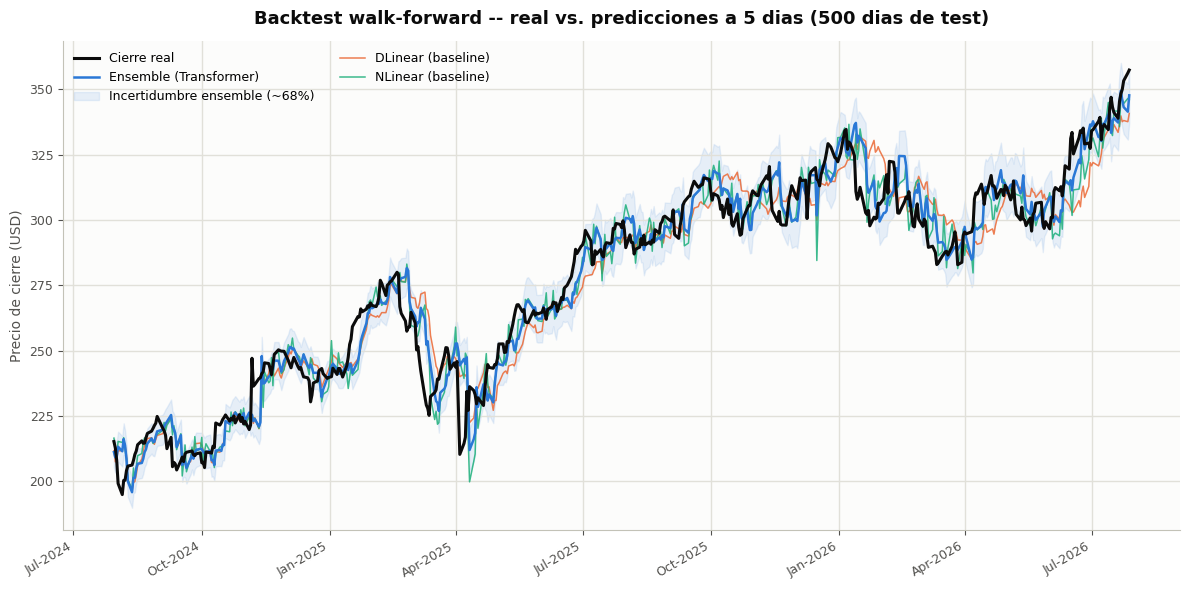

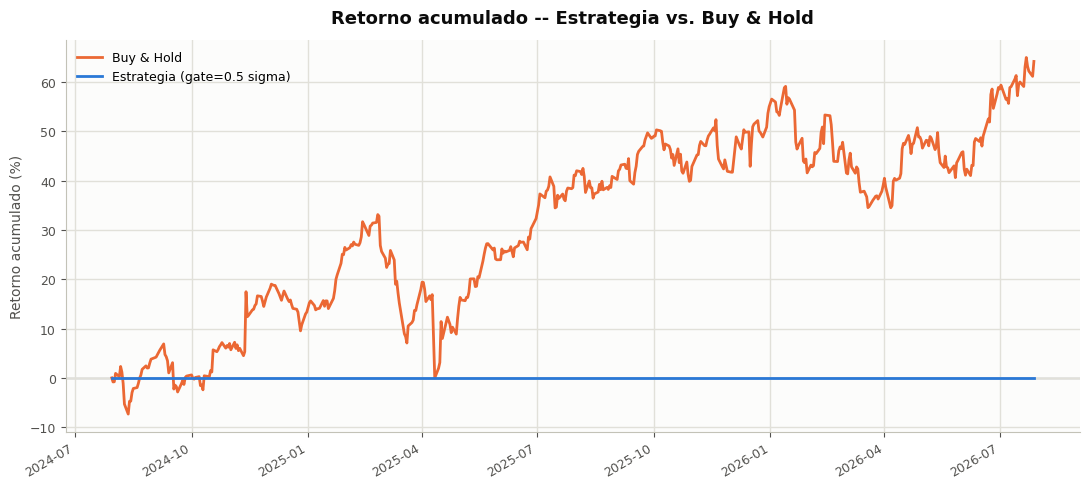

In [ ]:
# >>> QUE HACE ESTA CELDA: prueba el modelo contra ~2 anios de historia real
# >>> (no solo el dia de hoy) para saber si de verdad funciona mejor que el azar.
# >>> CUANDO CORRERLA: justo despues de SETUP, UNA SOLA VEZ (no hace falta
# >>> repetirla cada dia). Correla ANTES que INFORME para que el informe muestre
# >>> las metricas de validacion completas. Tarda bastante (minutos a un par de
# >>> horas) -- si no ves output todavia, esta bien, sigue corriendo.

# OJO -- tiempo de ejecucion: con N_TEST_DAYS_BACKTEST=500, RETRAIN_EVERY_BACKTEST=20
# (25 reentrenos) y N_SEEDS_BACKTEST=3, en CPU esto puede tardar bastante (decenas
# de minutos); en GPU de Colab deberia ser sensiblemente mas rapido. Si el tiempo
# de entrega es corto, bajar N_TEST_DAYS_BACKTEST y/o N_SEEDS_BACKTEST y/o EPOCHS_BACKTEST.
N_TEST_DAYS_BACKTEST = 500
RETRAIN_EVERY_BACKTEST = 20
EPOCHS_BACKTEST = 80
PATIENCE_BACKTEST = 15
# Progreso parcial del backtest -- NO es el resultado final (ese sigue siendo
# JPM_mejorado_backtest_resultados.csv, escrito solo al terminar todo el backtest).
# Si la celda se corta a mitad de camino (Colab se desconecta, se cuelga, se cierra
# la pestana), este archivo permite retomar desde el ultimo bloque guardado en vez
# de perder todo el trabajo y arrancar de cero.
BACKTEST_CHECKPOINT_PATH = os.path.join(DRIVE_FOLDER, 'JPM_mejorado_backtest_checkpoint.csv')


def walk_forward_backtest(df_feat, features, close_idx, sma_idx, lookback, horizon,
                           n_test_days, retrain_every, epochs, patience, n_seeds,
                           d_model, n_heads, d_ff, n_layers, dropout, quantiles,
                           checkpoint_path=None, verbose=True):
    '''Igual que antes, pero ahora guarda cada bloque de reentreno en
    `checkpoint_path` a medida que avanza (append, no reescritura completa) y
    retoma desde ahi si la celda se corta a mitad de camino -- antes, si Colab se
    desconectaba o el runtime se colgaba durante las horas que puede tardar el
    backtest completo, se perdia TODO el trabajo porque el unico guardado ocurria
    despues de terminar el loop entero.'''
    n = len(df_feat)
    serie_raw_full = df_feat[features].values.astype(float)
    close_full = df_feat['Close'].values.astype(float)
    dates_full = df_feat['Date'].values

    c_start_global = n - n_test_days - horizon
    c_end_global = n - horizon
    total_dias_planeados = c_end_global - c_start_global

    filas = []
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        filas = pd.read_csv(checkpoint_path, parse_dates=['fecha']).to_dict('records')
        if len(filas) > total_dias_planeados:
            print(f"  Aviso: el checkpoint tiene {len(filas)} dias, mas de los "
                  f"{total_dias_planeados} planeados con la configuracion actual "
                  f"(cambiaste N_TEST_DAYS_BACKTEST u otro parametro?) -- se ignora "
                  f"y arranca de cero. Borra {checkpoint_path} en Drive si no era lo que esperabas.")
            filas = []
        elif filas:
            print(f"  Checkpoint encontrado: {len(filas)}/{total_dias_planeados} dias ya "
                  f"procesados, retomando desde ahi en vez de arrancar de cero.")

    ultimo_bloque = None
    c_block_start = c_start_global + len(filas)
    while c_block_start < c_end_global:
        c_block_end = min(c_block_start + retrain_every, c_end_global)
        train_end = c_block_start + 1

        serie_train = serie_raw_full[:train_end]
        scaler_bt = MinMaxScaler((0, 1))
        scaler_bt.fit(serie_train)
        serie_norm_train = scaler_bt.transform(serie_train)

        X_tr, y_tr = build_windows_horizonte(serie_norm_train, lookback, horizon, target_idx=close_idx)
        last_close_w = X_tr[:, -1, close_idx]
        y_delta_tr = (y_tr - last_close_w).astype(np.float32).reshape(-1, 1)
        vol_tr = calcular_volatilidad_objetivo(close_full[:train_end], lookback, horizon, len(X_tr))

        n_val = max(1, int(len(X_tr) * 0.1))
        X_train_bt = torch.tensor(X_tr[:-n_val])
        y_train_bt = torch.tensor(y_delta_tr[:-n_val])
        vol_train_bt = torch.tensor(vol_tr[:-n_val])
        X_val_bt = torch.tensor(X_tr[-n_val:])
        y_val_bt = torch.tensor(y_delta_tr[-n_val:])
        vol_val_bt = torch.tensor(vol_tr[-n_val:])

        ensemble_bt = train_ensemble_mtl(n_seeds, len(features), d_model, n_heads, d_ff, n_layers, dropout,
                                          X_train_bt, y_train_bt, vol_train_bt, X_val_bt, y_val_bt, vol_val_bt,
                                          quantiles, epochs=epochs, patience=patience, verbose=False)
        torch.manual_seed(SEED)
        nlin_bt = NLinearBaseline(lookback, len(features))
        nlin_bt = train_linear_baseline(nlin_bt, X_train_bt, y_train_bt, X_val_bt, y_val_bt)
        torch.manual_seed(SEED)
        dlin_bt = DLinearBaseline(lookback, close_idx, sma_idx)
        dlin_bt = train_linear_baseline(dlin_bt, X_train_bt, y_train_bt, X_val_bt, y_val_bt)

        serie_norm_full = scaler_bt.transform(serie_raw_full)  # solo transform -> sin leakage

        filas_bloque = []
        for c in range(c_block_start, c_block_end):
            ventana = serie_norm_full[c - lookback + 1: c + 1, :][np.newaxis, ...].astype(np.float32)
            x_in = torch.tensor(ventana)

            pred_delta_scaled, pred_std_scaled = predict_ensemble_con_incertidumbre(ensemble_bt, x_in, n_mc=20)
            with torch.no_grad():
                pred_nlin_scaled = float(nlin_bt(x_in).item())
                pred_dlin_scaled = float(dlin_bt(x_in).item())

            ultimo_close_scaled = serie_norm_full[c, close_idx]
            precio_actual = close_full[c]
            precio_real_futuro = close_full[c + horizon]

            pred_ensemble = inverse_close(ultimo_close_scaled + pred_delta_scaled, scaler_bt, len(features), close_idx)
            pred_hi = inverse_close(ultimo_close_scaled + pred_delta_scaled + pred_std_scaled, scaler_bt, len(features), close_idx)
            pred_nlin = inverse_close(ultimo_close_scaled + pred_nlin_scaled, scaler_bt, len(features), close_idx)
            pred_dlin = inverse_close(ultimo_close_scaled + pred_dlin_scaled, scaler_bt, len(features), close_idx)
            pred_std_precio = abs(pred_hi - pred_ensemble)  # incertidumbre en unidades de precio, no escalado 0-1

            filas_bloque.append({
                'fecha': dates_full[c + horizon], 'precio_actual': precio_actual, 'real': precio_real_futuro,
                'pred_ensemble': pred_ensemble, 'pred_std': pred_std_precio,
                'pred_nlin': pred_nlin, 'pred_dlin': pred_dlin, 'baseline_naive': precio_actual,
            })

        filas.extend(filas_bloque)
        if checkpoint_path is not None:
            # Se guarda SOLO el bloque nuevo (append), no todo `filas` de nuevo --
            # reescribir el archivo entero en cada bloque arriesgaria corromperlo si
            # el corte ocurre justo durante esa escritura (lo mismo que tratamos de evitar).
            pd.DataFrame(filas_bloque).to_csv(
                checkpoint_path, mode='a', header=not os.path.exists(checkpoint_path), index=False
            )
        if verbose:
            print(f"  Reentreno hasta indice {train_end} ({dates_full[train_end-1]}) -> "
                  f"{c_block_end - c_block_start} dias de test procesados "
                  f"({len(filas)}/{total_dias_planeados} en total, guardado en disco)")
        ultimo_bloque = (ensemble_bt, X_val_bt, y_val_bt)
        c_block_start = c_block_end

    resultados = pd.DataFrame(filas)
    # Normaliza el tipo de 'fecha': las filas que vienen del checkpoint (leidas con
    # pd.read_csv) y las recien calculadas en esta corrida pueden traer tipos de
    # fecha distintos (Timestamp vs. numpy.datetime64) si se mezclan tal cual -- el
    # mismo tipo de inconsistencia que rompia el matching de fechas en
    # `segmentar_por_regimen` (ver su docstring). pd.to_datetime() las unifica.
    resultados['fecha'] = pd.to_datetime(resultados['fecha'])
    return resultados, ultimo_bloque


def segmentar_por_regimen(df_feat, resultados, horizon, ventana_vol=20):
    '''Nota de correccion: la version original hacia el match de fechas con un
    diccionario Python ({fecha: indice}), lo que puede fallar silenciosamente si
    las fechas llegan como numpy.datetime64 de un lado y pandas.Timestamp del
    otro (el hash de ambos tipos no siempre coincide segun la version de
    pandas/numpy) -- eso dejaba `vol_regimen` completamente vacio y rompia
    pd.qcut con bin edges en NaN. Se reemplaza por DatetimeIndex.get_indexer,
    que hace el match de forma vectorizada y no depende de que los hashes
    coincidan entre representaciones de fecha distintas.'''
    close_full = df_feat['Close'].values.astype(float)
    log_ret = np.diff(np.log(close_full))
    fechas_ret = pd.DatetimeIndex(df_feat['Date'].values[1:])
    vol_rolling = pd.Series(log_ret, index=fechas_ret).rolling(ventana_vol).std()

    resultados = resultados.copy()
    fechas_objetivo = pd.DatetimeIndex(pd.to_datetime(resultados['fecha']))
    posiciones = fechas_ret.get_indexer(fechas_objetivo)
    idx_vol = posiciones - horizon - 1
    validos = (posiciones != -1) & (idx_vol >= 0) & (idx_vol < len(vol_rolling))
    regimenes = np.full(len(resultados), np.nan)
    regimenes[validos] = vol_rolling.values[idx_vol[validos]]
    resultados['vol_regimen'] = regimenes
    resultados = resultados.dropna(subset=['vol_regimen'])

    if len(resultados) < 6 or resultados['vol_regimen'].nunique() < 3:
        print("  (No hay suficientes datos con regimen valido para segmentar en terciles esta vez -- se omite esta tabla.)")
        return pd.DataFrame(columns=['n', 'MAE_ensemble', 'MAE_naive', 'precision_direccional_pct'])

    resultados['tercil_vol'] = pd.qcut(resultados['vol_regimen'], 3, labels=['baja', 'media', 'alta'], duplicates='drop')

    reporte = resultados.groupby('tercil_vol', observed=True).apply(
        lambda g: pd.Series({
            'n': len(g),
            'MAE_ensemble': g['err_ensemble'].abs().mean(),
            'MAE_naive': g['err_naive'].abs().mean(),
            'precision_direccional_pct': 100 * np.mean(
                np.sign(g['pred_ensemble'] - g['precio_actual']) == np.sign(g['real'] - g['precio_actual'])
            ),
        }), include_groups=False
    )
    return reporte


def barrer_umbral_gate(resultados, umbrales, horizon):
    filas = []
    retorno_realizado = (resultados['real'] - resultados['precio_actual']) / resultados['precio_actual']
    for k in umbrales:
        cambio = resultados['pred_ensemble'] - resultados['precio_actual']
        pos = np.where(cambio > k * resultados['pred_std'], 1,
                        np.where(cambio < -k * resultados['pred_std'], -1, 0))
        retorno_estrategia = pos * retorno_realizado
        n_operaciones = int(np.sum(pos != 0))
        retorno_acumulado = retorno_estrategia.sum() * 100
        sharpe = (retorno_estrategia.mean() / retorno_estrategia.std() * np.sqrt(252 / horizon)
                  if retorno_estrategia.std() > 0 else np.nan)
        filas.append({'umbral_sigma': k, 'n_operaciones': n_operaciones,
                       'retorno_acumulado_pct': round(retorno_acumulado, 2),
                       'sharpe': round(sharpe, 3) if not np.isnan(sharpe) else np.nan})
    return pd.DataFrame(filas)


def max_drawdown_de_serie(equity_curve):
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / np.where(running_max == 0, 1, running_max)
    return float(drawdown.min()) * 100


print(f"Corriendo backtest walk-forward sobre {N_TEST_DAYS_BACKTEST} dias "
      f"({N_TEST_DAYS_BACKTEST/252:.1f} anios aprox.), reentrenando cada {RETRAIN_EVERY_BACKTEST} dias...")
resultados_bt, ultimo_bloque_bt = walk_forward_backtest(
    df_actual.assign(SMA_5=lambda d: d['Close'].rolling(5).mean(),
                      Volume_log=lambda d: np.log1p(d['Volume'].astype(float))).dropna(subset=['SMA_5', 'Volume_log']).reset_index(drop=True),
    FEATURES, CLOSE_IDX, SMA_IDX, LOOKBACK, HORIZON_INFORME,
    n_test_days=N_TEST_DAYS_BACKTEST, retrain_every=RETRAIN_EVERY_BACKTEST,
    epochs=EPOCHS_BACKTEST, patience=PATIENCE_BACKTEST, n_seeds=N_SEEDS_BACKTEST,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS, dropout=DROPOUT, quantiles=QUANTILES,
    checkpoint_path=BACKTEST_CHECKPOINT_PATH,
)

resultados_bt['err_ensemble'] = resultados_bt['real'] - resultados_bt['pred_ensemble']
resultados_bt['err_nlin'] = resultados_bt['real'] - resultados_bt['pred_nlin']
resultados_bt['err_dlin'] = resultados_bt['real'] - resultados_bt['pred_dlin']
resultados_bt['err_naive'] = resultados_bt['real'] - resultados_bt['baseline_naive']
resultados_bt.to_csv(os.path.join(DRIVE_FOLDER, 'JPM_mejorado_backtest_resultados.csv'), index=False)

mae = {c: resultados_bt[f'err_{c}'].abs().mean() for c in ['ensemble', 'nlin', 'dlin', 'naive']}
rmse = {c: np.sqrt((resultados_bt[f'err_{c}'] ** 2).mean()) for c in ['ensemble', 'nlin', 'dlin', 'naive']}
precision_direccional = 100 * np.mean(
    np.sign(resultados_bt['pred_ensemble'] - resultados_bt['precio_actual']) ==
    np.sign(resultados_bt['real'] - resultados_bt['precio_actual'])
)

w_stat, w_p = wilcoxon(resultados_bt['err_ensemble'].abs(), resultados_bt['err_naive'].abs())
dm_stat, dm_p = diebold_mariano_test(resultados_bt['err_ensemble'].values, resultados_bt['err_naive'].values, h=HORIZON_INFORME)
dm_stat_dlin, dm_p_dlin = diebold_mariano_test(resultados_bt['err_ensemble'].values, resultados_bt['err_dlin'].values, h=HORIZON_INFORME)
dm_stat_nlin, dm_p_nlin = diebold_mariano_test(resultados_bt['err_ensemble'].values, resultados_bt['err_nlin'].values, h=HORIZON_INFORME)
obs_boot, p_boot, ci_boot = block_bootstrap_test(resultados_bt['err_ensemble'].values, resultados_bt['err_naive'].values)

reporte_regimen = segmentar_por_regimen(df_actual, resultados_bt, HORIZON_INFORME)
tabla_umbrales = barrer_umbral_gate(resultados_bt, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5], HORIZON_INFORME)

if ultimo_bloque_bt is not None:
    ensemble_shuffle, X_val_shuffle, y_val_shuffle = ultimo_bloque_bt
    mse_orig, mse_shuf = shuffle_ablation(ensemble_shuffle, X_val_shuffle, y_val_shuffle, n_repeats=5)
else:
    # El checkpoint ya tenia TODOS los dias planeados -- no se reentreno nada en
    # esta corrida, asi que no hay un ensemble fresco de este backtest para la
    # ablacion de shuffling.
    mse_orig, mse_shuf = None, None

# equity curve de la estrategia con el GATE_SIGMA configurado en la celda de INFORME
cambio_pred = resultados_bt['pred_ensemble'] - resultados_bt['precio_actual']
pos_final = np.where(cambio_pred > GATE_SIGMA * resultados_bt['pred_std'], 1,
                      np.where(cambio_pred < -GATE_SIGMA * resultados_bt['pred_std'], -1, 0))
retorno_realizado_final = (resultados_bt['real'] - resultados_bt['precio_actual']) / resultados_bt['precio_actual']
retorno_estrategia_final = pos_final * retorno_realizado_final
equity_estrategia = 1 + retorno_estrategia_final.cumsum()
max_dd_estrategia = max_drawdown_de_serie(equity_estrategia.values)
retorno_acum_estrategia = retorno_estrategia_final.sum() * 100
sharpe_estrategia = (retorno_estrategia_final.mean() / retorno_estrategia_final.std() * np.sqrt(252 / HORIZON_INFORME)
                      if retorno_estrategia_final.std() > 0 else np.nan)

precios_periodo = df_actual[df_actual['Date'].isin(resultados_bt['fecha'])].sort_values('Date')['Close'].values
if len(precios_periodo) < 2:
    precios_periodo = resultados_bt.sort_values('fecha')['real'].values
equity_bh = precios_periodo / precios_periodo[0]
max_dd_bh = max_drawdown_de_serie(equity_bh)
retorno_acum_bh = (precios_periodo[-1] / precios_periodo[0] - 1) * 100
retornos_diarios_bh = np.diff(precios_periodo) / precios_periodo[:-1]
sharpe_bh = (retornos_diarios_bh.mean() / retornos_diarios_bh.std() * np.sqrt(252)
             if retornos_diarios_bh.std() > 0 else np.nan)

BACKTEST_METRICS.update({
    'periodo': f"{resultados_bt['fecha'].min().date()} a {resultados_bt['fecha'].max().date()} ({len(resultados_bt)} dias)",
    'MAE_ensemble': round(mae['ensemble'], 4), 'MAE_naive': round(mae['naive'], 4),
    'MAE_dlinear': round(mae['dlin'], 4), 'MAE_nlinear': round(mae['nlin'], 4),
    'RMSE_ensemble': round(rmse['ensemble'], 4), 'RMSE_naive': round(rmse['naive'], 4),
    'precision_direccional_pct': round(precision_direccional, 1),
    'wilcoxon_p_value': round(w_p, 4),
    'diebold_mariano_p_value': round(dm_p, 4) if not np.isnan(dm_p) else None,
    'diebold_mariano_vs_dlinear_p_value': round(dm_p_dlin, 4) if not np.isnan(dm_p_dlin) else None,
    'diebold_mariano_vs_nlinear_p_value': round(dm_p_nlin, 4) if not np.isnan(dm_p_nlin) else None,
    'block_bootstrap_p_value': round(p_boot, 4),
    'block_bootstrap_ci': (round(ci_boot[0], 4), round(ci_boot[1], 4)),
    'retorno_acumulado_estrategia_pct': round(retorno_acum_estrategia, 2),
    'sharpe_estrategia': round(sharpe_estrategia, 3) if not np.isnan(sharpe_estrategia) else None,
    'max_drawdown_estrategia_pct': round(max_dd_estrategia, 2),
    'retorno_acumulado_buy_hold_pct': round(retorno_acum_bh, 2),
    'sharpe_buy_hold': round(sharpe_bh, 3) if not np.isnan(sharpe_bh) else None,
    'max_drawdown_buy_hold_pct': round(max_dd_bh, 2),
})

print("\n" + "=" * 68)
print("RESULTADOS DEL BACKTEST RIGUROSO (version mejorada)")
print("=" * 68)
print(f"Periodo: {BACKTEST_METRICS['periodo']}")
print(f"MAE      -- ensemble={mae['ensemble']:.4f} | naive={mae['naive']:.4f} | "
      f"DLinear={mae['dlin']:.4f} | NLinear={mae['nlin']:.4f}")
print(f"RMSE     -- ensemble={rmse['ensemble']:.4f} | naive={rmse['naive']:.4f}")
print(f"Precision direccional (ensemble): {precision_direccional:.1f}%")
print(f"Wilcoxon (ensemble vs naive):            p={w_p:.4f}")
print(f"Diebold-Mariano (ensemble vs naive):      p={dm_p:.4f}" if not np.isnan(dm_p) else "Diebold-Mariano (ensemble vs naive): N/A")
print(f"Diebold-Mariano (ensemble vs DLinear):    p={dm_p_dlin:.4f}" if not np.isnan(dm_p_dlin) else "  N/A")
print(f"Diebold-Mariano (ensemble vs NLinear):    p={dm_p_nlin:.4f}" if not np.isnan(dm_p_nlin) else "  N/A")
print(f"Block-bootstrap (ensemble vs naive):      p={p_boot:.4f} (IC95% diff. error abs.: {ci_boot})")
if mse_orig is not None:
    print(f"Shuffle ablation -- MSE original={mse_orig:.6f} | MSE shuffled={mse_shuf:.6f} "
          f"(degradacion: {(mse_shuf/mse_orig - 1)*100:+.1f}%; si es ~0%, el modelo no esta "
          f"usando realmente el orden temporal)")
else:
    print("Shuffle ablation: N/A (no se reentreno ningun bloque nuevo en esta corrida)")
print("\nDesempeno por regimen de volatilidad:")
print(reporte_regimen)
print("\nBarrido de umbral del gate de confianza:")
print(tabla_umbrales)
print(f"\nEstrategia (gate={GATE_SIGMA} sigma) -- Retorno acumulado={retorno_acum_estrategia:.2f}% | "
      f"Sharpe={sharpe_estrategia:.3f} | Max Drawdown={max_dd_estrategia:.2f}%")
print(f"Buy & Hold                        -- Retorno acumulado={retorno_acum_bh:.2f}% | "
      f"Sharpe={sharpe_bh:.3f} | Max Drawdown={max_dd_bh:.2f}%")

print("\n" + "=" * 68)
print("COMPARACION vs. SCRIPT ORIGINAL (JPMorgan_Transformer_General.ipynb)")
print("=" * 68)
print("Original (146 dias, 1 semilla, sin baseline lineal, sin DM/bootstrap):")
print("  MAE=7.2838 | RMSE=9.1745 | Precision direccional=56.2% | Wilcoxon p=0.190")
print("  Retorno estrategia=-0.97% | Sharpe estrategia=-1.309 | Buy&Hold=+9.60% (Sharpe 0.725)")
print(f"Mejorado ({len(resultados_bt)} dias, ensemble x{N_SEEDS_BACKTEST}, +volumen, +DLinear/NLinear, +DM/bootstrap):")
print(f"  MAE={mae['ensemble']:.4f} | RMSE={rmse['ensemble']:.4f} | "
      f"Precision direccional={precision_direccional:.1f}% | Wilcoxon p={w_p:.4f} | DM p={dm_p:.4f}")
print(f"  Retorno estrategia={retorno_acum_estrategia:.2f}% | Sharpe estrategia={sharpe_estrategia:.3f} | "
      f"Buy&Hold={retorno_acum_bh:.2f}% (Sharpe {sharpe_bh:.3f})")


def graficar_backtest_walkforward(resultados_bt, horizon):
    '''Vista principal del backtest: precio real vs. las 4 series de prediccion
    a lo largo de todo el periodo de test walk-forward.'''
    r = resultados_bt.sort_values('fecha')
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(r['fecha'], r['real'], color=INK, linewidth=2.2, label='Cierre real', zorder=5)
    ax.plot(r['fecha'], r['pred_ensemble'], color=SLOT_AZUL, linewidth=1.8, label='Ensemble (Transformer)', zorder=4)
    ax.fill_between(r['fecha'], r['pred_ensemble'] - r['pred_std'], r['pred_ensemble'] + r['pred_std'],
                     color=SLOT_AZUL, alpha=0.10, zorder=1, label='Incertidumbre ensemble (~68%)')
    ax.plot(r['fecha'], r['pred_dlin'], color=SLOT_NARANJA, linewidth=1.1, alpha=0.85,
            label='DLinear (baseline)', zorder=3)
    ax.plot(r['fecha'], r['pred_nlin'], color=SLOT_AQUA, linewidth=1.1, alpha=0.85,
            label='NLinear (baseline)', zorder=3)
    _estilo_base(ax, f'Backtest walk-forward -- real vs. predicciones a {horizon} dias ({len(r)} dias de test)',
                 'Precio de cierre (USD)')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    ax.legend(loc='best', fontsize=9, frameon=False, ncol=2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


def graficar_equity_curve(resultados_bt, gate_sigma, horizon):
    r = resultados_bt.sort_values('fecha').copy()
    cambio = r['pred_ensemble'] - r['precio_actual']
    pos = np.where(cambio > gate_sigma * r['pred_std'], 1,
                    np.where(cambio < -gate_sigma * r['pred_std'], -1, 0))
    retorno_realizado = (r['real'] - r['precio_actual']) / r['precio_actual']
    equity_estrategia = 1 + (pos * retorno_realizado).cumsum()
    equity_bh = r['precio_actual'] / r['precio_actual'].iloc[0]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(r['fecha'], (equity_bh - 1) * 100, color=SLOT_NARANJA, linewidth=2, label='Buy & Hold', zorder=3)
    ax.plot(r['fecha'], (equity_estrategia - 1) * 100, color=SLOT_AZUL, linewidth=2,
            label=f'Estrategia (gate={gate_sigma} sigma)', zorder=4)
    ax.axhline(0, color=MUTED, linewidth=1, linestyle='-', zorder=1)
    _estilo_base(ax, 'Retorno acumulado -- Estrategia vs. Buy & Hold', 'Retorno acumulado (%)')
    ax.legend(loc='best', fontsize=9, frameon=False)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


import matplotlib.dates as mdates
graficar_backtest_walkforward(resultados_bt, HORIZON_INFORME)
graficar_equity_curve(resultados_bt, GATE_SIGMA, HORIZON_INFORME)


## Informe completo de decision (a 5 dias)

Igual que en el original: ciclo diario a 1 dia arriba, informe de decision
completo a 5 dias aqui. Diferencias:

- La prediccion es un **ensemble** de `N_SEEDS_LIVE` modelos, no uno solo.
- Se muestran, a modo de contraste, las predicciones de **NLinear** y
  **DLinear** junto a la del ensemble -- si el baseline lineal da una lectura
  muy distinta (o mas razonable), es una senal de alerta sobre la prediccion
  del Transformer para ese dia puntual.
- El **gate de confianza** ahora usa un umbral configurable (`GATE_SIGMA`, no
  fijo en 1.0 como el original) -- ajustalo segun la tabla de barrido de umbral
  que arroja la celda de BACKTEST antes de decidir con dinero real.
- La celda de INFORME puede correrse antes o despues del BACKTEST; si se corre
  antes, el resumen de validacion queda con placeholders (`None`) hasta que
  corras el BACKTEST al menos una vez en la sesion.


INFORME DE PREDICCION (MEJORADO) -- JPMorgan Chase & Co. (NYSE:JPM) -- version mejorada
Fecha de la prediccion:        2026-08-12
Precio actual:                  365.18
Precio esperado (5d, ensemble): 366.41
  ...segun NLinear (baseline):  365.58
  ...segun DLinear (baseline):  357.65
Retorno esperado:               +0.34%
Nivel de confianza:             0.11 sigma (gate configurado en 0.50 sigma)
Volatilidad estimada:           10.99
Recomendacion:                  MANTENER
Justificacion:                  El cambio predicho (+0.34%) no supera 0.50 desvios estandar de la incertidumbre propia del modelo (0.11 sigma) -- no hay conviccion suficiente para recomendar una operacion.
Take profit:                    None
Stop loss:                      None
--------------------------------------------------------------------
Validacion del modelo (backtest historico riguroso, periodo: Corre la celda de BACKTEST antes para completar este resumen )
  MAE -- ensemble=None | naive=None | DLinear=N

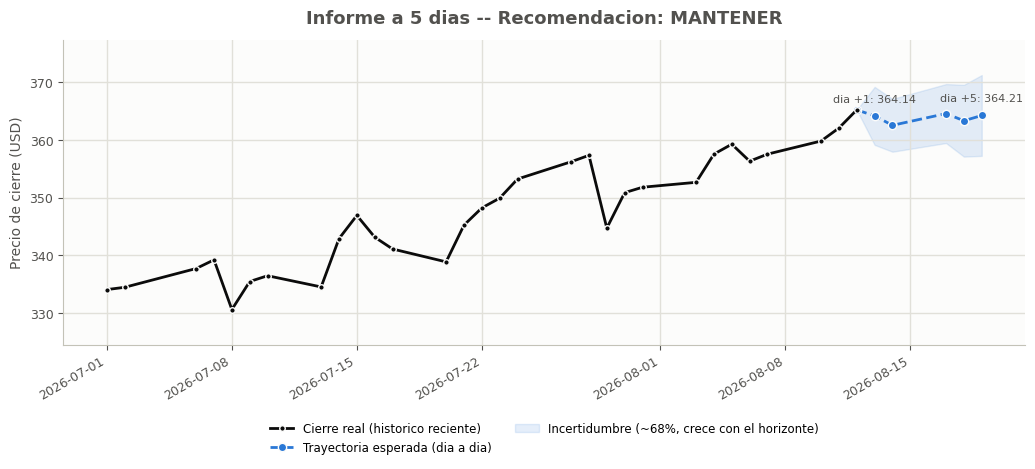

In [9]:
# >>> QUE HACE ESTA CELDA: entrena un modelo a 5 dias y arma la recomendacion
# >>> completa (comprar/mantener/vender) con take profit y stop loss.
# >>> CUANDO CORRERLA: despues de BACKTEST (asi el resumen de validacion sale
# >>> completo, no con 'None'). Repetila cuando necesites decidir una operacion real.


def generar_informe_mejorado(activo, df_confirmado, features, lookback, horizon,
                              d_model, n_heads, d_ff, n_layers, dropout,
                              n_seeds, quantiles, gate_sigma, backtest_metrics,
                              epochs=100, patience=15):
    close_idx = features.index('Close')
    sma_idx = features.index('SMA_5')
    n_features = len(features)

    df = df_confirmado.copy()
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['Volume_log'] = np.log1p(df['Volume'].astype(float))
    df = df.dropna(subset=['SMA_5', 'Volume_log']).reset_index(drop=True)

    scaler_local = MinMaxScaler(feature_range=(0, 1))
    serie_norm_local = scaler_local.fit_transform(df[features].values.astype(float))

    X_all, y_all = build_windows_horizonte(serie_norm_local, lookback, horizon, target_idx=close_idx)
    last_close_window = X_all[:, -1, close_idx]
    y_delta = (y_all - last_close_window).reshape(-1, 1).astype(np.float32)
    vol_target = calcular_volatilidad_objetivo(df['Close'].values.astype(float), lookback, horizon, len(X_all))

    n_val = max(1, int(len(X_all) * 0.1))
    X_train = torch.tensor(X_all[:-n_val], device=device)
    y_train = torch.tensor(y_delta[:-n_val], device=device)
    vol_train = torch.tensor(vol_target[:-n_val], device=device)
    X_val = torch.tensor(X_all[-n_val:], device=device)
    y_val = torch.tensor(y_delta[-n_val:], device=device)
    vol_val = torch.tensor(vol_target[-n_val:], device=device)

    ensemble_local = train_ensemble_mtl(n_seeds, n_features, d_model, n_heads, d_ff, n_layers, dropout,
                                         X_train, y_train, vol_train, X_val, y_val, vol_val,
                                         quantiles, epochs=epochs, patience=patience, verbose=False)

    torch.manual_seed(SEED)
    nlin_local = NLinearBaseline(lookback, n_features)
    nlin_local = train_linear_baseline(nlin_local, X_train, y_train, X_val, y_val)
    torch.manual_seed(SEED)
    dlin_local = DLinearBaseline(lookback, close_idx, sma_idx)
    dlin_local = train_linear_baseline(dlin_local, X_train, y_train, X_val, y_val)

    ultima_ventana = serie_norm_local[-lookback:, :]
    x_input = torch.tensor(ultima_ventana[np.newaxis, ...], dtype=torch.float32, device=device)
    pred_mean_scaled, pred_std_scaled = predict_ensemble_con_incertidumbre(ensemble_local, x_input, n_mc=50)
    with torch.no_grad():
        pred_nlin_scaled = float(nlin_local(x_input).item())
        pred_dlin_scaled = float(dlin_local(x_input).item())

    ultimo_close_scaled = serie_norm_local[-1, close_idx]
    precio_actual = float(df['Close'].iloc[-1])
    fecha_actual = df['Date'].iloc[-1]
    precio_esperado = float(inverse_close(ultimo_close_scaled + pred_mean_scaled, scaler_local, n_features, close_idx))
    precio_hi = float(inverse_close(ultimo_close_scaled + pred_mean_scaled + pred_std_scaled, scaler_local, n_features, close_idx))
    precio_lo = float(inverse_close(ultimo_close_scaled + pred_mean_scaled - pred_std_scaled, scaler_local, n_features, close_idx))
    precio_nlin = float(inverse_close(ultimo_close_scaled + pred_nlin_scaled, scaler_local, n_features, close_idx))
    precio_dlin = float(inverse_close(ultimo_close_scaled + pred_dlin_scaled, scaler_local, n_features, close_idx))
    volatilidad_estimada = abs(precio_hi - precio_esperado)

    retorno_esperado_pct = (precio_esperado - precio_actual) / precio_actual * 100
    cambio_predicho = precio_esperado - precio_actual
    señal_confiable = abs(cambio_predicho) > gate_sigma * volatilidad_estimada
    nivel_confianza_sigma = abs(cambio_predicho) / volatilidad_estimada if volatilidad_estimada > 0 else 0.0

    if señal_confiable and cambio_predicho > 0:
        recomendacion = 'COMPRAR'
        justificacion = (f"El modelo (ensemble de {n_seeds} semillas) predice una subida de "
                          f"{retorno_esperado_pct:+.2f}% en {horizon} dias habiles, y ese cambio supera "
                          f"{gate_sigma:.2f} desvios estandar de la incertidumbre propia del modelo "
                          f"({nivel_confianza_sigma:.2f} sigma). Backtest: precision direccional "
                          f"{backtest_metrics.get('precision_direccional_pct')}%, Wilcoxon p="
                          f"{backtest_metrics.get('wilcoxon_p_value')}, Diebold-Mariano p="
                          f"{backtest_metrics.get('diebold_mariano_p_value')}.")
        take_profit = precio_hi
        stop_loss = precio_actual - volatilidad_estimada
    elif señal_confiable and cambio_predicho < 0:
        recomendacion = 'VENDER'
        justificacion = (f"El modelo predice una caida de {retorno_esperado_pct:+.2f}% en {horizon} dias "
                          f"habiles, y ese cambio supera {gate_sigma:.2f} desvios estandar de la "
                          f"incertidumbre propia del modelo ({nivel_confianza_sigma:.2f} sigma).")
        take_profit = precio_lo
        stop_loss = precio_actual + volatilidad_estimada
    else:
        recomendacion = 'MANTENER'
        justificacion = (f"El cambio predicho ({retorno_esperado_pct:+.2f}%) no supera "
                          f"{gate_sigma:.2f} desvios estandar de la incertidumbre propia del modelo "
                          f"({nivel_confianza_sigma:.2f} sigma) -- no hay conviccion suficiente para "
                          f"recomendar una operacion.")
        take_profit = None
        stop_loss = None

    informe = {
        'activo': activo,
        'fecha_prediccion': fecha_actual.date() if hasattr(fecha_actual, 'date') else fecha_actual,
        'precio_actual': round(precio_actual, 2),
        'precio_esperado_ensemble': round(precio_esperado, 2),
        'precio_esperado_nlinear': round(precio_nlin, 2),
        'precio_esperado_dlinear': round(precio_dlin, 2),
        'horizonte_dias': horizon,
        'retorno_esperado_pct': round(retorno_esperado_pct, 2),
        'nivel_confianza_sigma': round(nivel_confianza_sigma, 2),
        'gate_sigma_usado': gate_sigma,
        'volatilidad_estimada': round(volatilidad_estimada, 2),
        'recomendacion': recomendacion,
        'justificacion': justificacion,
        'take_profit': round(take_profit, 2) if take_profit is not None else None,
        'stop_loss': round(stop_loss, 2) if stop_loss is not None else None,
        'backtest': backtest_metrics,
    }
    return informe, ensemble_local, (nlin_local, dlin_local), scaler_local


def imprimir_informe_mejorado(informe):
    b = informe['backtest']
    print("=" * 68)
    print(f"INFORME DE PREDICCION (MEJORADO) -- {informe['activo']}")
    print("=" * 68)
    print(f"Fecha de la prediccion:        {informe['fecha_prediccion']}")
    print(f"Precio actual:                  {informe['precio_actual']}")
    print(f"Precio esperado ({informe['horizonte_dias']}d, ensemble): {informe['precio_esperado_ensemble']}")
    print(f"  ...segun NLinear (baseline):  {informe['precio_esperado_nlinear']}")
    print(f"  ...segun DLinear (baseline):  {informe['precio_esperado_dlinear']}")
    print(f"Retorno esperado:               {informe['retorno_esperado_pct']:+.2f}%")
    print(f"Nivel de confianza:             {informe['nivel_confianza_sigma']:.2f} sigma "
          f"(gate configurado en {informe['gate_sigma_usado']:.2f} sigma)")
    print(f"Volatilidad estimada:           {informe['volatilidad_estimada']}")
    print(f"Recomendacion:                  {informe['recomendacion']}")
    print(f"Justificacion:                  {informe['justificacion']}")
    print(f"Take profit:                    {informe['take_profit']}")
    print(f"Stop loss:                      {informe['stop_loss']}")
    print("-" * 68)
    print("Validacion del modelo (backtest historico riguroso, periodo:", b.get('periodo'), ")")
    print(f"  MAE -- ensemble={b.get('MAE_ensemble')} | naive={b.get('MAE_naive')} | "
          f"DLinear={b.get('MAE_dlinear')} | NLinear={b.get('MAE_nlinear')}")
    print(f"  Precision direccional={b.get('precision_direccional_pct')}%")
    print(f"  Wilcoxon p={b.get('wilcoxon_p_value')} | Diebold-Mariano p={b.get('diebold_mariano_p_value')} | "
          f"Block-bootstrap p={b.get('block_bootstrap_p_value')}")
    print(f"  Retorno acumulado -- Estrategia={b.get('retorno_acumulado_estrategia_pct')}% | "
          f"Buy&Hold={b.get('retorno_acumulado_buy_hold_pct')}%")
    print(f"  Sharpe -- Estrategia={b.get('sharpe_estrategia')} | Buy&Hold={b.get('sharpe_buy_hold')}")
    print("=" * 68)


informe_actual, _modelo_informe, _baselines_informe, _scaler_informe = generar_informe_mejorado(
    activo="JPMorgan Chase & Co. (NYSE:JPM) -- version mejorada",
    df_confirmado=df_actual,
    features=FEATURES, lookback=LOOKBACK, horizon=HORIZON_INFORME,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS, dropout=DROPOUT,
    n_seeds=N_SEEDS_LIVE, quantiles=QUANTILES, gate_sigma=GATE_SIGMA,
    backtest_metrics=BACKTEST_METRICS,
)
imprimir_informe_mejorado(informe_actual)


def graficar_informe_fan_chart(df_confirmado, informe, trayectoria=None, dias_historia=30):
    '''"Cono" de incertidumbre para la prediccion a horizonte del informe. Si se
    pasa `trayectoria` (lista de puntos dia-a-dia de `entrenar_trayectoria_precio`),
    dibuja el camino completo (1 a N dias) con la banda de incertidumbre creciendo
    dia a dia; si no, cae al comportamiento anterior (un solo punto en el horizonte
    final). Take profit / stop loss y el color del titulo siguen anclados a la
    recomendacion del modelo validado (horizonte fijo), no a la trayectoria.'''
    color_recomendacion = {'COMPRAR': GOOD, 'VENDER': CRITICAL, 'MANTENER': INK_SECUNDARIA}[informe['recomendacion']]

    hist = df_confirmado.tail(dias_historia)
    fecha_hoy = hist['Date'].iloc[-1]

    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    ax.plot(hist['Date'], hist['Close'], color=INK, linewidth=2, marker='o', markersize=4,
            markerfacecolor=INK, markeredgecolor=SURFACE, label='Cierre real (historico reciente)', zorder=5)

    if trayectoria:
        fechas_path = [fecha_hoy] + [p['fecha'] for p in trayectoria]
        precios_path = [informe['precio_actual']] + [p['precio_esperado'] for p in trayectoria]
        lo_path = [informe['precio_actual']] + [p['precio_lo'] for p in trayectoria]
        hi_path = [informe['precio_actual']] + [p['precio_hi'] for p in trayectoria]

        ax.plot(fechas_path, precios_path, color=SLOT_AZUL, linewidth=2, linestyle='--',
                marker='o', markersize=6, markerfacecolor=SLOT_AZUL, markeredgecolor=SURFACE,
                zorder=4, label='Trayectoria esperada (dia a dia)')
        ax.fill_between(fechas_path, lo_path, hi_path, color=SLOT_AZUL, alpha=0.12, zorder=1,
                         label='Incertidumbre (~68%, crece con el horizonte)')
        ax.annotate(f"dia +1: {precios_path[1]:.2f}", (fechas_path[1], precios_path[1]),
                    textcoords="offset points", xytext=(0, 10), fontsize=8, color=INK_SECUNDARIA, ha='center')
        ax.annotate(f"dia +{trayectoria[-1]['horizon']}: {precios_path[-1]:.2f}", (fechas_path[-1], precios_path[-1]),
                    textcoords="offset points", xytext=(0, 10), fontsize=8, color=INK_SECUNDARIA, ha='center')
        fecha_horizonte = fechas_path[-1]
    else:
        fecha_horizonte = fecha_hoy + pd.tseries.offsets.BDay(informe['horizonte_dias'])
        precio_hi = informe['precio_esperado_ensemble'] + informe['volatilidad_estimada']
        precio_lo = informe['precio_esperado_ensemble'] - informe['volatilidad_estimada']
        ax.plot([fecha_hoy, fecha_horizonte], [informe['precio_actual'], informe['precio_esperado_ensemble']],
                color=SLOT_AZUL, linewidth=2, linestyle='--', zorder=4, label='Prediccion ensemble')
        ax.fill_between([fecha_hoy, fecha_horizonte], [informe['precio_actual'], precio_lo],
                         [informe['precio_actual'], precio_hi], color=SLOT_AZUL, alpha=0.12, zorder=1,
                         label='Incertidumbre (~68%)')
        ax.scatter([fecha_horizonte], [informe['precio_esperado_ensemble']], color=SLOT_AZUL, s=130,
                   edgecolor=SURFACE, linewidth=1.5, zorder=6)

    if informe['take_profit'] is not None:
        ax.axhline(informe['take_profit'], color=GOOD, linewidth=1.2, linestyle=':', zorder=2,
                   label=f"Take profit ({informe['take_profit']})")
    if informe['stop_loss'] is not None:
        ax.axhline(informe['stop_loss'], color=CRITICAL, linewidth=1.2, linestyle=':', zorder=2,
                   label=f"Stop loss ({informe['stop_loss']})")

    _estilo_base(ax, f"Informe a {informe['horizonte_dias']} dias -- Recomendacion: {informe['recomendacion']}",
                 'Precio de cierre (USD)')
    ax.title.set_color(color_recomendacion)
    ax.margins(y=0.15)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=8.5, frameon=False)
    fig.autofmt_xdate()
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()


# ============================================================
# TRAYECTORIA DIA-A-DIA (1 a HORIZON_INFORME) -- solo para visualizar el
# "camino" esperado con su incertidumbre creciendo dia a dia. Prediccion
# directa multi-horizonte (TFT-style DMS): un mismo modelo predice todos los
# horizontes de una sola pasada, no encadena un horizonte sobre el anterior
# (eso acumularia error -- Zhou et al. 2021). OJO: esto es un modelo SEPARADO
# del que arma la recomendacion de arriba (COMPRAR/MANTENER/VENDER, que sigue
# siendo el modelo de horizonte fijo, ya validado por el backtest). Este solo
# aporta contexto visual de la trayectoria -- los dias intermedios (1 a 4) NO
# estan sometidos al mismo test estadistico riguroso que el dia 5.
# ============================================================

HORIZONTES_PATH = list(range(1, HORIZON_INFORME + 1))


def build_windows_multihorizonte(data, lookback, horizons, target_idx=0):
    max_h = max(horizons)
    X, y = [], []
    for i in range(len(data) - lookback - max_h + 1):
        ventana = data[i:i + lookback, :]
        ultimo_close = ventana[-1, target_idx]
        deltas = [data[i + lookback + h - 1, target_idx] - ultimo_close for h in horizons]
        X.append(ventana)
        y.append(deltas)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class TransformerForecasterMultiHorizonte(nn.Module):
    '''Misma arquitectura del Transformer multi-tarea, pero con la cabeza de
    cuantiles mas ancha: 3 cuantiles POR CADA horizonte de HORIZONTES_PATH, de
    una sola pasada hacia adelante.'''
    def __init__(self, n_features, d_model, n_heads, d_ff, n_layers, n_horizons, n_quantiles=3, dropout=0.1):
        super().__init__()
        self.n_horizons = n_horizons
        self.n_quantiles = n_quantiles
        self.embedding = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head_quantiles = nn.Linear(d_model, n_horizons * n_quantiles)
        self.head_vol = nn.Linear(d_model, 1)

    def forward(self, x):
        z = self.embedding(x)
        z = self.pos_encoder(z)
        z = self.encoder(z)
        z_last = z[:, -1, :]
        q = self.head_quantiles(z_last).view(-1, self.n_horizons, self.n_quantiles)
        vol = torch.nn.functional.softplus(self.head_vol(z_last))
        return q, vol


def pinball_loss_multihorizonte(preds, target, quantiles):
    losses = []
    for i, q in enumerate(quantiles):
        e = target - preds[:, :, i]
        losses.append(torch.max((q - 1) * e, q * e))
    return torch.mean(torch.stack(losses, dim=-1))


def train_model_multihorizonte(model, X_train, y_train, vol_train, X_val, y_val, vol_val,
                                quantiles, lambda_vol=0.1, epochs=100, lr=1e-3, batch_size=32,
                                patience=15, verbose=False):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    mse = nn.MSELoss()
    best_val, best_state, patience_ctr = float('inf'), None, 0
    n_train = X_train.shape[0]
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n_train)
        running = 0.0
        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb, vb = X_train[idx], y_train[idx], vol_train[idx]
            optimizer.zero_grad()
            q_pred, vol_pred = model(xb)
            loss = pinball_loss_multihorizonte(q_pred, yb, quantiles) + lambda_vol * mse(vol_pred, vb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        running /= n_train
        model.eval()
        with torch.no_grad():
            q_val, vol_val_pred = model(X_val)
            val_loss = (pinball_loss_multihorizonte(q_val, y_val, quantiles) + lambda_vol * mse(vol_val_pred, vol_val)).item()
        if val_loss < best_val:
            best_val, best_state, patience_ctr = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
        if verbose and (epoch == 1 or epoch % 20 == 0):
            print(f"  Epoca {epoch:3d} | train={running:.6f} | val={val_loss:.6f}")
        if patience_ctr >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def predict_multihorizonte_con_incertidumbre(model, x_input, n_mc=50):
    model.train()
    qs = []
    with torch.no_grad():
        for _ in range(n_mc):
            q, _ = model(x_input)
            qs.append(q.cpu().numpy()[0])
    model.eval()
    qs = np.array(qs)
    q_mean = qs.mean(axis=0)
    epistemic_std = qs[:, :, 1].std(axis=0)
    aleatoric_std = (q_mean[:, 2] - q_mean[:, 0]) / 2.563
    return q_mean, epistemic_std, aleatoric_std


def train_ensemble_multihorizonte(n_seeds, n_features, d_model, n_heads, d_ff, n_layers, n_horizons, dropout,
                                   X_train, y_train, vol_train, X_val, y_val, vol_val,
                                   quantiles, epochs, patience, verbose=False):
    modelos = []
    for s in range(n_seeds):
        torch.manual_seed(2000 + s)
        m = TransformerForecasterMultiHorizonte(n_features, d_model, n_heads, d_ff, n_layers, n_horizons, len(quantiles), dropout)
        m = train_model_multihorizonte(m, X_train, y_train, vol_train, X_val, y_val, vol_val,
                                        quantiles, epochs=epochs, patience=patience, verbose=verbose)
        modelos.append(m)
    return modelos


def predict_ensemble_multihorizonte_con_incertidumbre(modelos, x_input, n_mc=50):
    medias_por_modelo, var_intra_por_modelo, aleatoric_por_modelo = [], [], []
    for m in modelos:
        q_mean, epi_std, ale_std = predict_multihorizonte_con_incertidumbre(m, x_input, n_mc=n_mc)
        medias_por_modelo.append(q_mean[:, 1])
        var_intra_por_modelo.append(epi_std ** 2)
        aleatoric_por_modelo.append(ale_std ** 2)
    medias_por_modelo = np.array(medias_por_modelo)
    pred_final = medias_por_modelo.mean(axis=0)
    var_total = np.mean(var_intra_por_modelo, axis=0) + medias_por_modelo.var(axis=0) + np.mean(aleatoric_por_modelo, axis=0)
    return pred_final, np.sqrt(var_total)


def entrenar_trayectoria_precio(df_confirmado, features, lookback, horizontes,
                                 d_model, n_heads, d_ff, n_layers, dropout,
                                 n_seeds, quantiles, epochs=100, patience=15):
    '''Entrena el ensemble multi-horizonte y arma la trayectoria dia-a-dia de
    precio esperado + banda de incertidumbre, anclada a la fecha mas reciente
    confirmada.'''
    close_idx = features.index('Close')
    n_features = len(features)

    df = df_confirmado.copy()
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['Volume_log'] = np.log1p(df['Volume'].astype(float))
    df = df.dropna(subset=['SMA_5', 'Volume_log']).reset_index(drop=True)

    scaler_local = MinMaxScaler(feature_range=(0, 1))
    serie_norm_local = scaler_local.fit_transform(df[features].values.astype(float))

    X_all, y_all = build_windows_multihorizonte(serie_norm_local, lookback, horizontes, target_idx=close_idx)
    vol_target = calcular_volatilidad_objetivo(df['Close'].values.astype(float), lookback, max(horizontes), len(X_all))

    n_val = max(1, int(len(X_all) * 0.1))
    X_train = torch.tensor(X_all[:-n_val], device=device)
    y_train = torch.tensor(y_all[:-n_val], device=device)
    vol_train = torch.tensor(vol_target[:-n_val], device=device)
    X_val = torch.tensor(X_all[-n_val:], device=device)
    y_val = torch.tensor(y_all[-n_val:], device=device)
    vol_val = torch.tensor(vol_target[-n_val:], device=device)

    ensemble_path = train_ensemble_multihorizonte(
        n_seeds, n_features, d_model, n_heads, d_ff, n_layers, len(horizontes), dropout,
        X_train, y_train, vol_train, X_val, y_val, vol_val, quantiles, epochs=epochs, patience=patience,
    )

    ultima_ventana = serie_norm_local[-lookback:, :]
    x_input = torch.tensor(ultima_ventana[np.newaxis, ...], dtype=torch.float32, device=device)
    pred_final, std_final = predict_ensemble_multihorizonte_con_incertidumbre(ensemble_path, x_input, n_mc=50)

    ultimo_close_scaled = serie_norm_local[-1, close_idx]
    precio_actual = float(df['Close'].iloc[-1])
    fecha_hoy = df['Date'].iloc[-1]

    trayectoria = []
    for i, h in enumerate(horizontes):
        precio_h = inverse_close(ultimo_close_scaled + pred_final[i], scaler_local, n_features, close_idx)
        precio_hi = inverse_close(ultimo_close_scaled + pred_final[i] + std_final[i], scaler_local, n_features, close_idx)
        precio_lo = inverse_close(ultimo_close_scaled + pred_final[i] - std_final[i], scaler_local, n_features, close_idx)
        fecha_h = fecha_hoy + pd.tseries.offsets.BDay(h)
        trayectoria.append({
            'horizon': h, 'fecha': fecha_h,
            'precio_esperado': round(float(precio_h), 2),
            'precio_hi': round(float(precio_hi), 2),
            'precio_lo': round(float(precio_lo), 2),
        })
    return trayectoria


trayectoria_precio = entrenar_trayectoria_precio(
    df_confirmado=df_actual, features=FEATURES, lookback=LOOKBACK, horizontes=HORIZONTES_PATH,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS, dropout=DROPOUT,
    n_seeds=N_SEEDS_LIVE, quantiles=QUANTILES,
)
print("\nTrayectoria dia a dia (contexto visual, no validada individualmente por dia):")
for punto in trayectoria_precio:
    print(f"  dia +{punto['horizon']} ({punto['fecha'].date()}): {punto['precio_esperado']}  "
          f"[{punto['precio_lo']}, {punto['precio_hi']}]")

graficar_informe_fan_chart(df_actual, informe_actual, trayectoria_precio)


In [8]:
# >>> QUE HACE ESTA CELDA: entrena con lo confirmado hasta hoy y predice a ciegas
# >>> el cierre del proximo dia habil (1 dia adelante).
# >>> CUANDO CORRERLA: una vez por dia, cuando quieras un pronostico nuevo.

df_train_full = df_actual.copy()
df_train_full['SMA_5'] = df_train_full['Close'].rolling(window=5).mean()
df_train_full['Volume_log'] = np.log1p(df_train_full['Volume'].astype(float))
df_train_full = df_train_full.dropna(subset=['SMA_5', 'Volume_log']).reset_index(drop=True)
print(f"Entrenando con {len(df_train_full)} filas (hasta {df_train_full['Date'].max().date()})")

serie = df_train_full[FEATURES].values.astype(float)
scaler = MinMaxScaler(feature_range=(0, 1))
serie_norm = scaler.fit_transform(serie)

X_all, y_all = build_windows_horizonte(serie_norm, LOOKBACK, HORIZON, target_idx=CLOSE_IDX)
ultimo_close_ventana = X_all[:, -1, CLOSE_IDX]
y_delta = (y_all - ultimo_close_ventana).astype(np.float32).reshape(-1, 1)
vol_target = calcular_volatilidad_objetivo(df_train_full['Close'].values.astype(float), LOOKBACK, HORIZON, len(X_all))

n_val = max(1, int(len(X_all) * 0.1))
X_train = torch.tensor(X_all[:-n_val], device=device)
y_train = torch.tensor(y_delta[:-n_val], device=device)
vol_train = torch.tensor(vol_target[:-n_val], device=device)
X_val = torch.tensor(X_all[-n_val:], device=device)
y_val = torch.tensor(y_delta[-n_val:], device=device)
vol_val = torch.tensor(vol_target[-n_val:], device=device)
print(f"Ventanas de entrenamiento: {X_train.shape[0]} | Ventanas de validacion: {X_val.shape[0]}")

ensemble = train_ensemble_mtl(N_SEEDS_LIVE, N_FEATURES, D_MODEL, N_HEADS, D_FF, N_LAYERS, DROPOUT,
                               X_train, y_train, vol_train, X_val, y_val, vol_val,
                               QUANTILES, epochs=150, patience=20, verbose=True)

ultima_ventana = serie_norm[-LOOKBACK:, :]
x_input = torch.tensor(ultima_ventana[np.newaxis, ...], dtype=torch.float32, device=device)
pred_mean_scaled, pred_std_scaled = predict_ensemble_con_incertidumbre(ensemble, x_input, n_mc=50)

ultimo_close_scaled = serie_norm[-1, CLOSE_IDX]
pred_scaled = ultimo_close_scaled + pred_mean_scaled
pred_scaled_hi = ultimo_close_scaled + pred_mean_scaled + pred_std_scaled
pred_scaled_lo = ultimo_close_scaled + pred_mean_scaled - pred_std_scaled

prediccion_actual = float(inverse_close(pred_scaled, scaler, N_FEATURES, close_idx=CLOSE_IDX))
prediccion_hi = float(inverse_close(pred_scaled_hi, scaler, N_FEATURES, close_idx=CLOSE_IDX))
prediccion_lo = float(inverse_close(pred_scaled_lo, scaler, N_FEATURES, close_idx=CLOSE_IDX))
baseline_actual = float(df_train_full['Close'].iloc[-1])
fecha_base = df_train_full['Date'].iloc[-1]

amplitud_incertidumbre = abs(prediccion_hi - prediccion_actual)
cambio_predicho = abs(prediccion_actual - baseline_actual)
senal_confiable = cambio_predicho > amplitud_incertidumbre

print("\n================ PREDICCION A CIEGAS (ensemble x{}) ================".format(N_SEEDS_LIVE))
print(f"Ultimo cierre conocido ({fecha_base.date()}): {baseline_actual:.2f}")
print(f"Prediccion ensemble: {prediccion_actual:.2f}  (intervalo ~68%: [{prediccion_lo:.2f}, {prediccion_hi:.2f}])")
print(f"Baseline naive (persistencia): {baseline_actual:.2f}")
if senal_confiable:
    print("Senal: CONFIABLE -- el cambio predicho supera la incertidumbre del propio modelo.")
else:
    print("Senal: DEBIL -- la incertidumbre del modelo es mayor que el cambio predicho. "
          "No se recomienda tomar una decision de inversion en base a esta prediccion puntual.")
print("Corre la celda de REVELACION y escribi la fecha + cierre real cuando lo sepas.")




Entrenando con 3167 filas (hasta 2026-08-12)
Ventanas de entrenamiento: 2842 | Ventanas de validacion: 315
  Epoca   1 | train_loss=0.036183 | val_loss=0.008709
  Epoca  20 | train_loss=0.002457 | val_loss=0.003819
  Early stopping en la epoca 37 (mejor val_loss=0.003259)
  Epoca   1 | train_loss=0.027554 | val_loss=0.012186
  Epoca  20 | train_loss=0.002203 | val_loss=0.003353
  Epoca  40 | train_loss=0.001828 | val_loss=0.003331
  Epoca  60 | train_loss=0.001687 | val_loss=0.003314
  Early stopping en la epoca 78 (mejor val_loss=0.003259)
  Epoca   1 | train_loss=0.036504 | val_loss=0.018965
  Epoca  20 | train_loss=0.002842 | val_loss=0.003866
  Epoca  40 | train_loss=0.002005 | val_loss=0.003618
  Epoca  60 | train_loss=0.001660 | val_loss=0.003305
  Epoca  80 | train_loss=0.001605 | val_loss=0.003354
  Early stopping en la epoca 88 (mejor val_loss=0.003255)
  Epoca   1 | train_loss=0.030698 | val_loss=0.007816
  Epoca  20 | train_loss=0.002595 | val_loss=0.003476
  Epoca  40 | tra

Fecha del cierre real que vas a ingresar (DD/MM/AAAA): 12/08/2026
Cierre real (Close) del 12/08/2026: 365.18
Volumen (Vol.) del 12/08/2026, formato Investing.com (ej. 6.25M): 4.37

Error ensemble: 2.51 (0.69%) | Error baseline: 3.14 (0.86%) | Direccion correcta: True

Tabla de resultados acumulada (13 predicciones):
fecha_prediccion  prediccion  baseline   real  error_transformer  error_baseline  error_pct_transformer  error_pct_baseline  direccion_correcta
      2026-07-28  356.593605    356.20 357.31           0.716395            1.11               0.200497            0.310655                True
      2026-07-29  357.649678    357.31 344.71          12.939678           12.60               3.753787            3.655246               False
      2026-07-30  345.598373    344.71 350.85           5.251627            6.14               1.496830            1.750036                True
      2026-07-31  351.404165    350.85 351.79           0.385835            0.94               0.109678   

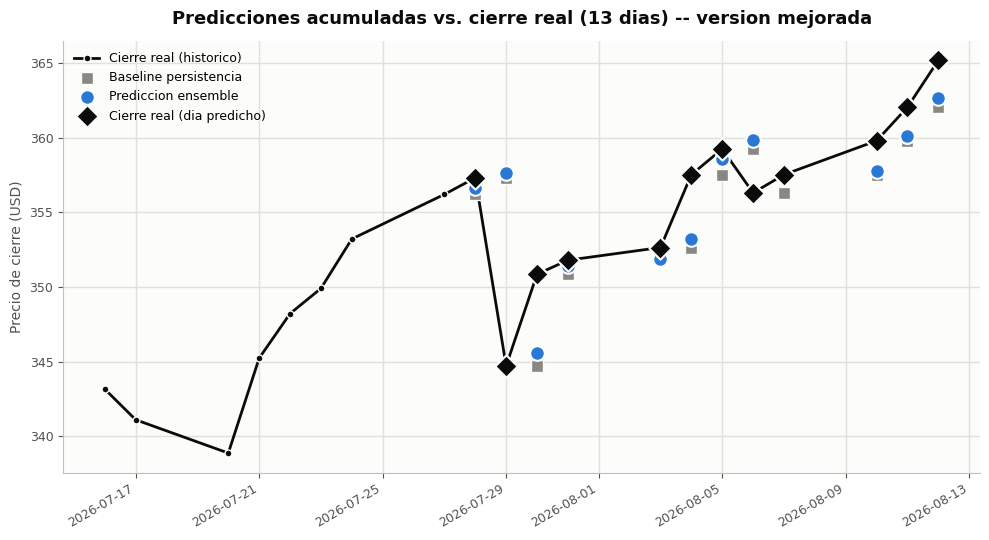


Para predecir el siguiente dia, volve a correr la celda de PREDICCION.


In [7]:
import pandas as pd
import numpy as np

# >>> QUE HACE ESTA CELDA: te pide el precio (y volumen) real del dia que
# >>> prediciste en 'predict', calcula el error, y lo guarda en tu historial.
# >>> CUANDO CORRERLA: justo despues de 'predict', cuando ya sepas el dato real.

fecha_real_str = input("Fecha del cierre real que vas a ingresar (DD/MM/AAAA): ")
fecha_real = pd.to_datetime(fecha_real_str, format='%d/%m/%Y')
real_close = float(input(f"Cierre real (Close) del {fecha_real_str}: "))
volumen_real_str = input(f"Volumen (Vol.) del {fecha_real_str}, formato Investing.com (ej. 6.25M): ")


def parse_volumen_simple(v):
    v = str(v).strip()
    mult = 1.0
    if v.endswith('M'):
        mult, v = 1e6, v[:-1]
    elif v.endswith('K'):
        mult, v = 1e3, v[:-1]
    elif v.endswith('B'):
        mult, v = 1e9, v[:-1]
    return float(v.replace(',', '')) * mult


volumen_real = parse_volumen_simple(volumen_real_str)

error_transformer = abs(prediccion_actual - real_close)
error_baseline = abs(baseline_actual - real_close)
error_pct_transformer = error_transformer / real_close * 100
error_pct_baseline = error_baseline / real_close * 100

direccion_predicha = 'sube' if prediccion_actual > baseline_actual else 'baja'
direccion_real = 'sube' if real_close > baseline_actual else 'baja'
direccion_correcta = direccion_predicha == direccion_real

nueva_fila = {
    'fecha_prediccion': fecha_real, 'prediccion': prediccion_actual, 'baseline': baseline_actual,
    'real': real_close, 'error_transformer': error_transformer, 'error_baseline': error_baseline,
    'error_pct_transformer': error_pct_transformer, 'error_pct_baseline': error_pct_baseline,
    'direccion_correcta': direccion_correcta
}
tabla_resultados = pd.concat([tabla_resultados, pd.DataFrame([nueva_fila])], ignore_index=True)
tabla_resultados.to_csv(RESULTADOS_PATH, index=False)

fila_ohlcv = {'Date': fecha_real, 'Open': None, 'Close': real_close, 'High': None, 'Low': None, 'Volume': volumen_real}
df_actual = pd.concat([df_actual, pd.DataFrame([fila_ohlcv])], ignore_index=True)
df_actual = df_actual.sort_values('Date').drop_duplicates(subset='Date', keep='last').reset_index(drop=True)
df_actual.to_csv(HIST_CONFIRMADO_PATH, index=False)

print(f"\nError ensemble: {error_transformer:.2f} ({error_pct_transformer:.2f}%) | "
      f"Error baseline: {error_baseline:.2f} ({error_pct_baseline:.2f}%) | "
      f"Direccion correcta: {direccion_correcta}")
print(f"\nTabla de resultados acumulada ({len(tabla_resultados)} predicciones):")
print(tabla_resultados.to_string(index=False))


def graficar_resultados_acumulados(df_hist, tabla, dias_zoom=20):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    df_zoom = df_hist.tail(dias_zoom)
    ax.plot(df_zoom['Date'], df_zoom['Close'], color=INK, linewidth=2,
            marker='o', markersize=5, markerfacecolor=INK, markeredgecolor=SURFACE,
            markeredgewidth=1, label='Cierre real (historico)', zorder=3)
    ax.scatter(tabla['fecha_prediccion'], tabla['baseline'], color=MUTED, s=70,
               marker='s', edgecolor=SURFACE, linewidth=1, zorder=4, label='Baseline persistencia')
    ax.scatter(tabla['fecha_prediccion'], tabla['prediccion'], color=SLOT_AZUL, s=110,
               marker='o', edgecolor=SURFACE, linewidth=1.5, zorder=5, label='Prediccion ensemble')
    ax.scatter(tabla['fecha_prediccion'], tabla['real'], color=INK, s=130,
               marker='D', edgecolor=SURFACE, linewidth=1.5, zorder=6, label='Cierre real (dia predicho)')
    _estilo_base(ax, f'Predicciones acumuladas vs. cierre real ({len(tabla)} dias) -- version mejorada',
                 'Precio de cierre (USD)')
    ax.legend(loc='best', fontsize=9, frameon=False)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


graficar_resultados_acumulados(df_actual, tabla_resultados)
print("\nPara predecir el siguiente dia, volve a correr la celda de PREDICCION.")

## Como leer la recomendacion antes de operar con dinero real (Hapi)

1. **Mira primero el nivel de confianza en sigma, no el retorno esperado en
   %.** Un retorno esperado de +2% no significa nada si la incertidumbre propia
   del modelo es de 4 puntos de precio -- el gate ya filtra esto por vos
   (recomienda MANTENER si `nivel_confianza_sigma < GATE_SIGMA`), pero conviene
   entender por que.
2. **Revisa que el backtest respalde la recomendacion, no solo la prediccion
   del dia.** Si Wilcoxon *y* Diebold-Mariano dan p > 0.05, el modelo no tiene
   una ventaja demostrada sobre simplemente no operar (o sobre comprar y
   mantener) -- una recomendacion puntual de COMPRAR ese dia sigue siendo, en el
   mejor de los casos, "la mas prometedora de varias pruebas que en conjunto no
   alcanzan significancia" (la misma conclusion honesta que el script original
   ya dejaba para JPM).
3. **Compara contra DLinear/NLinear.** Si el baseline lineal da una lectura muy
   distinta a la del ensemble, es una senal de que la prediccion del dia podria
   ser ruido de la arquitectura mas compleja, no senal real.
4. **Usa la tabla de barrido de umbral, no el umbral por default.** `GATE_SIGMA
   = 0.5` es un punto de partida razonable, pero la tabla te muestra el
   trade-off real para JPM especificamente: umbrales bajos generan mas
   operaciones (mas riesgo, mas oportunidad) y umbrales altos casi no operan
   (como le paso al script original con 1.0 sigma). Elegi el umbral mirando
   Sharpe y numero de operaciones, no solo retorno acumulado.
5. **Mira el regimen de volatilidad actual.** Si el modelo funciona
   sistematicamente peor en el regimen de "alta" volatilidad (columna
   `precision_direccional_pct` de la tabla de regimenes) y el mercado esta en
   ese regimen ahora, dale menos peso a la recomendacion del dia aunque el gate
   diga que es "confiable".
6. **Take profit / stop loss son el ancho de la incertidumbre, no una garantia.**
   Estan calculados como precio esperado +/- 1 desvio estandar del modelo -- son
   una referencia de gestion de riesgo, no un nivel que el precio vaya a
   respetar necesariamente.

En resumen: la version mejorada te da mas evidencia y mas formas de
contrastarla (baselines, tests, regimenes, sensibilidad al umbral), pero el
criterio final -- comprar solo cuando la senal es fuerte *y* el backtest la
respalda estadisticamente *y* estas comodo con el riesgo que implica el
horizonte de 5 dias -- sigue siendo el mismo que en el script original.
